In [ ]:
from google.colab import files
uploaded = files.upload()

Saving default of credit card clients.xls to default of credit card clients (1).xls


In [ ]:
import pandas as pd

#load Excel with correct header row (header =1 since header starts from second row)
df = pd.read_excel("default of credit card clients.xls", header =1)

#preview the data
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install xgboost

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

In [ ]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
df.drop(columns=["ID"], errors='ignore', inplace=True)

In [ ]:
df.rename(columns={"default payment next month": "default"}, inplace=True)

In [ ]:
df = df.apply(pd.to_numeric, errors='coerce')

In [ ]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
df.dtypes

,0
LIMIT_BAL,int64
SEX,int64
EDUCATION,int64
MARRIAGE,int64
AGE,int64
PAY_0,int64
PAY_2,int64
PAY_3,int64
PAY_4,int64
PAY_5,int64


In [ ]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='object')

In [ ]:
categorical_df = df.select_dtypes(include = 'object')
numerical_df = df.select_dtypes(exclude = 'object')

In [ ]:
print(f"There are {len(categorical_df.columns)} Categorical Attributes")
print(f"There are {len(numerical_df.columns)} Numerical Attributes")

There are 0 Categorical Attributes
There are 24 Numerical Attributes


In [ ]:
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


**EDA**

In [ ]:
#  Duplicate check
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 35


In [ ]:
# Drop duplicate rows
df = df.drop_duplicates()

# Confirm again
print(" Remaining Duplicates:", df.duplicated().sum())

 Remaining Duplicates: 0


In [ ]:
df.isnull().sum()

,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0
PAY_5,0


In [ ]:
print(df.info())
print(df['default'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 29965 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  29965 non-null  int64
 1   SEX        29965 non-null  int64
 2   EDUCATION  29965 non-null  int64
 3   MARRIAGE   29965 non-null  int64
 4   AGE        29965 non-null  int64
 5   PAY_0      29965 non-null  int64
 6   PAY_2      29965 non-null  int64
 7   PAY_3      29965 non-null  int64
 8   PAY_4      29965 non-null  int64
 9   PAY_5      29965 non-null  int64
 10  PAY_6      29965 non-null  int64
 11  BILL_AMT1  29965 non-null  int64
 12  BILL_AMT2  29965 non-null  int64
 13  BILL_AMT3  29965 non-null  int64
 14  BILL_AMT4  29965 non-null  int64
 15  BILL_AMT5  29965 non-null  int64
 16  BILL_AMT6  29965 non-null  int64
 17  PAY_AMT1   29965 non-null  int64
 18  PAY_AMT2   29965 non-null  int64
 19  PAY_AMT3   29965 non-null  int64
 20  PAY_AMT4   29965 non-null  int64
 21  PAY_AMT5   29965 

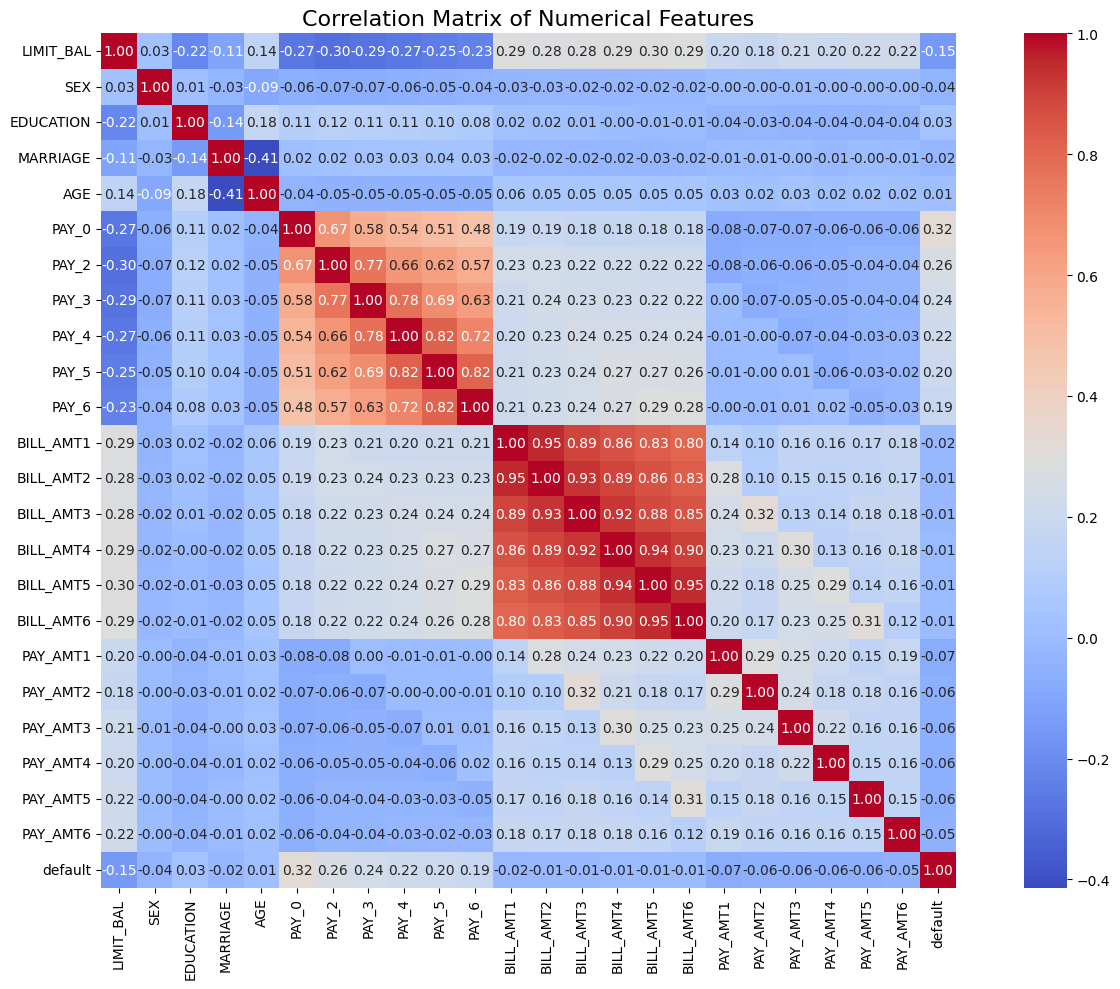

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix only on numeric columns
corrMatrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corrMatrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

/tmp/ipython-input-4273443142.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette='crest', ax=ax)


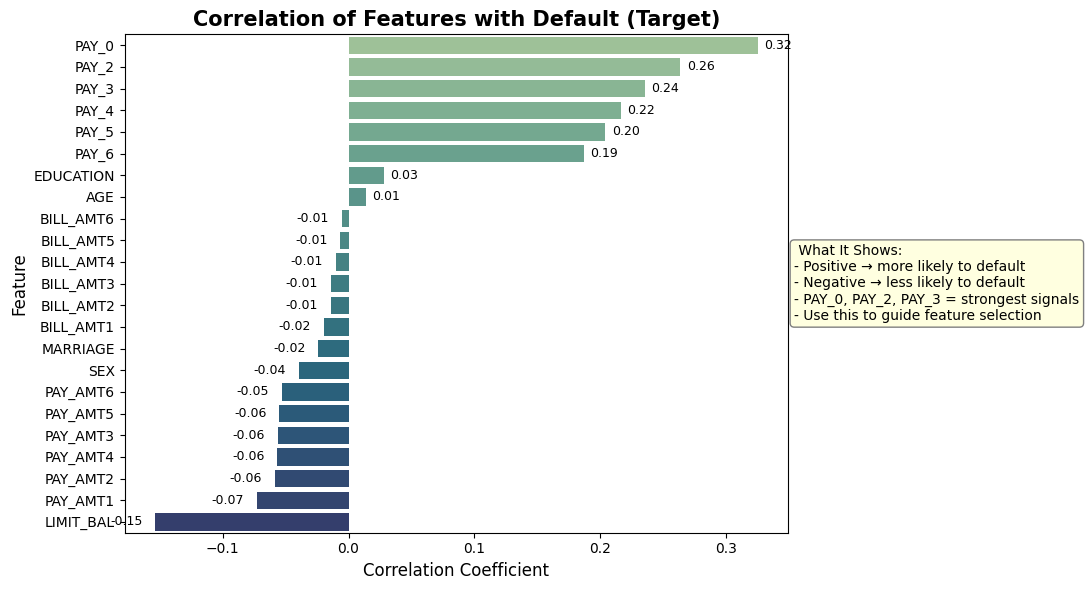

In [ ]:
# Correlation with target
target_corr = df.corr(numeric_only=True)['default'].drop('default').sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(11, 6))  # Wider plot
sns.barplot(x=target_corr.values, y=target_corr.index, palette='crest', ax=ax)

# Titles and axis labels
ax.set_title("Correlation of Features with Default (Target)", fontsize=15, fontweight='bold')
ax.set_xlabel("Correlation Coefficient", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)

# Add correlation values on bars
for i, (val, name) in enumerate(zip(target_corr.values, target_corr.index)):
    ax.text(val + 0.005 if val > 0 else val - 0.01, i,
            f"{val:.2f}", va='center', ha='left' if val > 0 else 'right', fontsize=9)

#  Explanation box on the side
explanation = (
    " What It Shows:\n"
    "- Positive → more likely to default\n"
    "- Negative → less likely to default\n"
    "- PAY_0, PAY_2, PAY_3 = strongest signals\n"
    "- Use this to guide feature selection"
)

# Add side box
ax.text(1.01, 0.5, explanation, transform=ax.transAxes,
        fontsize=10, va='center',
        bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))

# Adjust spacing to avoid cramping
plt.subplots_adjust(right=0.78)
plt.tight_layout()
plt.show()

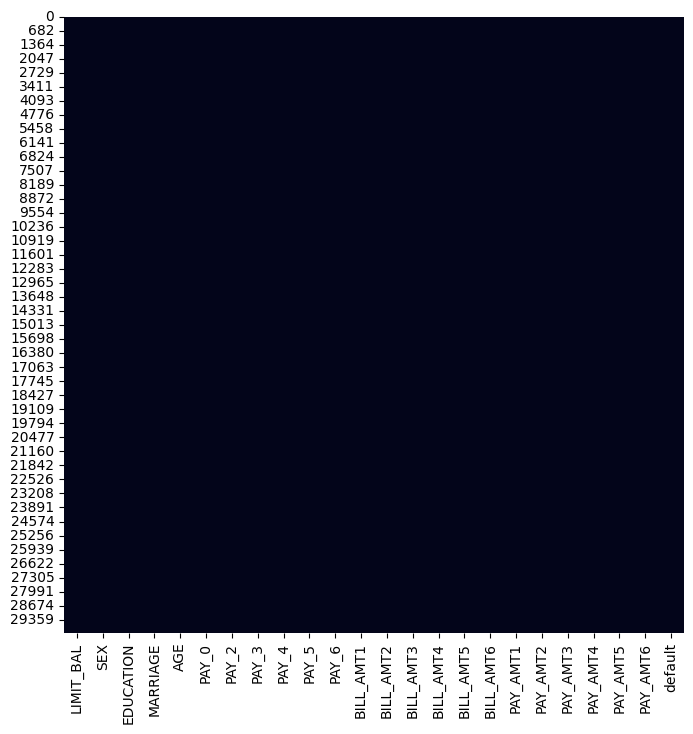

In [ ]:
plt.figure(figsize = (8,8))
sns.heatmap(df.isnull(), cbar = False);

In [ ]:
# percentage of missing values in each variable
df.isnull().sum()/len(df)*100

,0
LIMIT_BAL,0.0
SEX,0.0
EDUCATION,0.0
MARRIAGE,0.0
AGE,0.0
PAY_0,0.0
PAY_2,0.0
PAY_3,0.0
PAY_4,0.0
PAY_5,0.0


**univariate analysis**

In [ ]:
df['default'].describe()

,default
count,29965.000000
mean,0.221258
std,0.415101
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
df['default'].value_counts()

,count
default,
0,23335
1,6630


In [ ]:
df.drop(columns=["ID"], errors='ignore', inplace=True)
df.rename(columns={"default payment next month": "default"}, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')

In [ ]:
df['default_label'] = df['default'].map({0: 'No', 1: 'Yes'})

/tmp/ipython-input-3446738378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='default_label', palette='pastel')


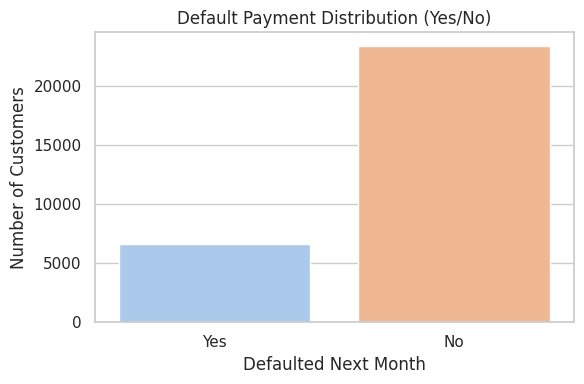

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='default_label', palette='pastel')
plt.title("Default Payment Distribution (Yes/No)")
plt.xlabel("Defaulted Next Month")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [ ]:
print("There is class imbalance in the target variable (22% Yes vs 78% No).")
print("This could bias the model, so we will consider applying imbalance techniques.")

There is class imbalance in the target variable (22% Yes vs 78% No).
This could bias the model, so we will consider applying imbalance techniques.


In [ ]:
sns.set(style="whitegrid")

 Pie Chart for: SEX (Gender)


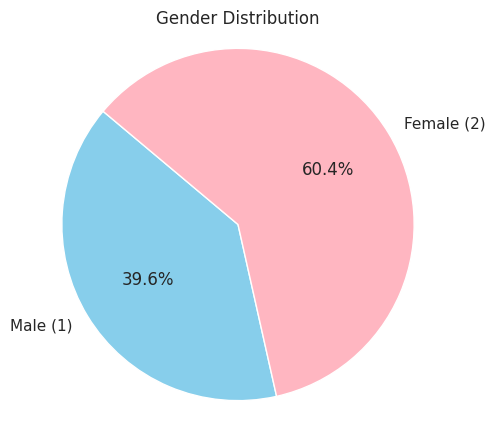

In [ ]:
print(" Pie Chart for: SEX (Gender)")
labels = ['Male (1)', 'Female (2)']
sizes = df['SEX'].value_counts().sort_index()
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightpink'])
plt.title("Gender Distribution")
plt.axis('equal')
plt.show()

 Bar Plot for: EDUCATION


/tmp/ipython-input-3752427898.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='EDUCATION_LAB', order=custom_order, palette='pastel')


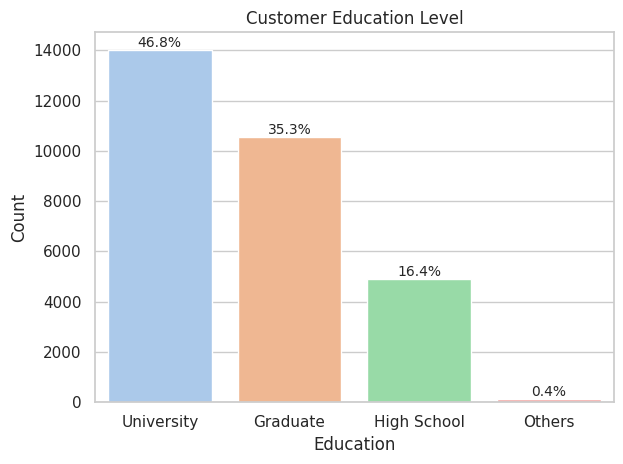

In [ ]:
print(" Bar Plot for: EDUCATION")
edu_labels = {1: 'Graduate', 2: 'University', 3: 'High School', 4: 'Others'}
df['EDUCATION_LAB'] = df['EDUCATION'].map(edu_labels)
custom_order = ['University', 'Graduate', 'High School', 'Others']
ax = sns.countplot(data=df, x='EDUCATION_LAB', order=custom_order, palette='pastel')
plt.title("Customer Education Level")
plt.xlabel("Education")
plt.ylabel("Count")
total = len(df)
for p in ax.patches:
    count = p.get_height()
    percent = count / total * 100
    ax.annotate(f'{percent:.1f}%',
                (p.get_x() + p.get_width() / 2, count),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

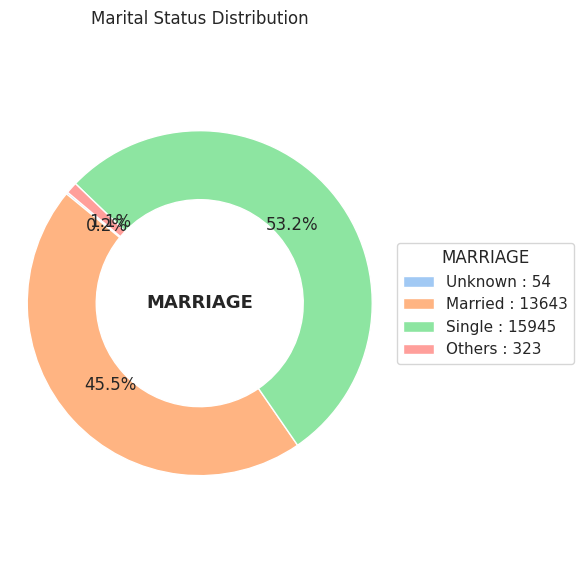

In [ ]:
sizes = df['MARRIAGE'].value_counts().sort_index()
labels = {1: 'Married', 2: 'Single', 3: 'Others', 0: 'Unknown', 4: 'Unlisted'}
legend = [f"{labels.get(i, 'Unknown')} : {v}" for i, v in sizes.items()]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, _, autotexts = ax.pie(sizes, autopct='%1.1f%%', startangle=140,
                              wedgeprops=dict(width=0.4),
                              colors=sns.color_palette("pastel"),
                              pctdistance=0.7)
ax.legend(wedges, legend, title="MARRIAGE", loc="center left", bbox_to_anchor=(1, 0.5))
ax.text(0, 0, 'MARRIAGE', ha='center', va='center', fontsize=13, fontweight='bold')
plt.title("Marital Status Distribution")
plt.axis('equal')
plt.tight_layout()
plt.show()

 Stacked Bar Chart for: Payment Status (PAY_0, PAY_2–PAY_6)


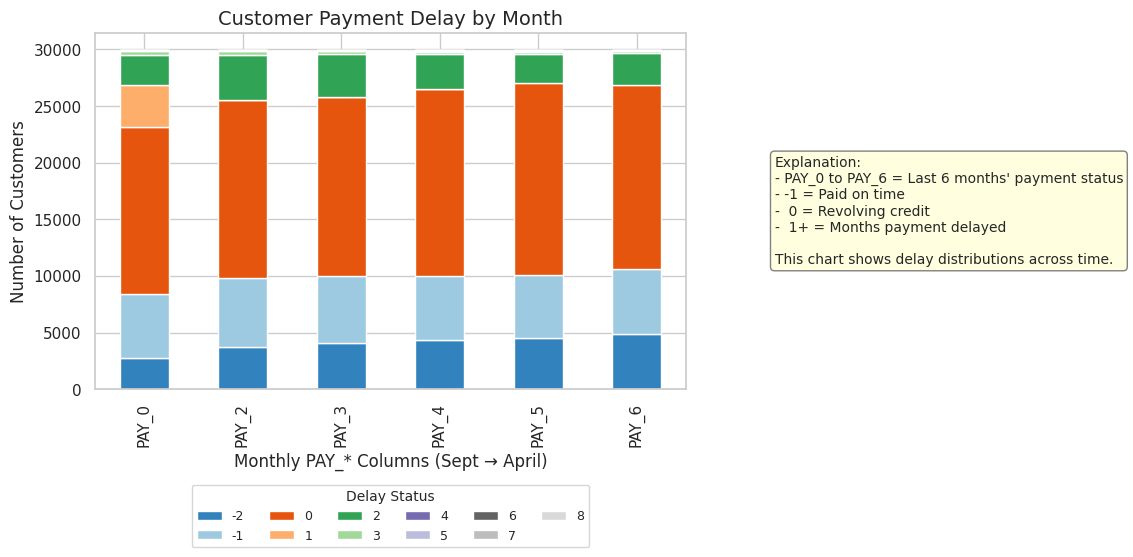

In [ ]:
print(" Stacked Bar Chart for: Payment Status (PAY_0, PAY_2–PAY_6)")

import matplotlib.pyplot as plt

pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
status_levels = sorted(set(val for col in pay_cols for val in df[col].unique()))
pay_data = pd.DataFrame({col: df[col].value_counts().reindex(status_levels, fill_value=0) for col in pay_cols})

fig, ax = plt.subplots(figsize=(12, 6))
pay_data.T.plot(kind='bar', stacked=True, ax=ax, colormap='tab20c')

ax.set_title("Customer Payment Delay by Month", fontsize=14)
ax.set_xlabel("Monthly PAY_* Columns (Sept → April)")
ax.set_ylabel("Number of Customers")

ax.legend(title="Delay Status", bbox_to_anchor=(0.5, -0.25), loc='upper center', ncol=6, fontsize=9, title_fontsize=10)

# Explanation box on the right (moved to avoid overlap)
explanation = (
    "Explanation:\n"
    "- PAY_0 to PAY_6 = Last 6 months' payment status\n"
    "- -1 = Paid on time\n"
    "-  0 = Revolving credit\n"
    "-  1+ = Months payment delayed\n\n"
    "This chart shows delay distributions across time."
)

ax.text(1.15, 0.5, explanation, transform=ax.transAxes,
        fontsize=10, va='center', bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))

plt.tight_layout()
plt.show()

 Histogram for: LIMIT_BAL (Credit Limit)


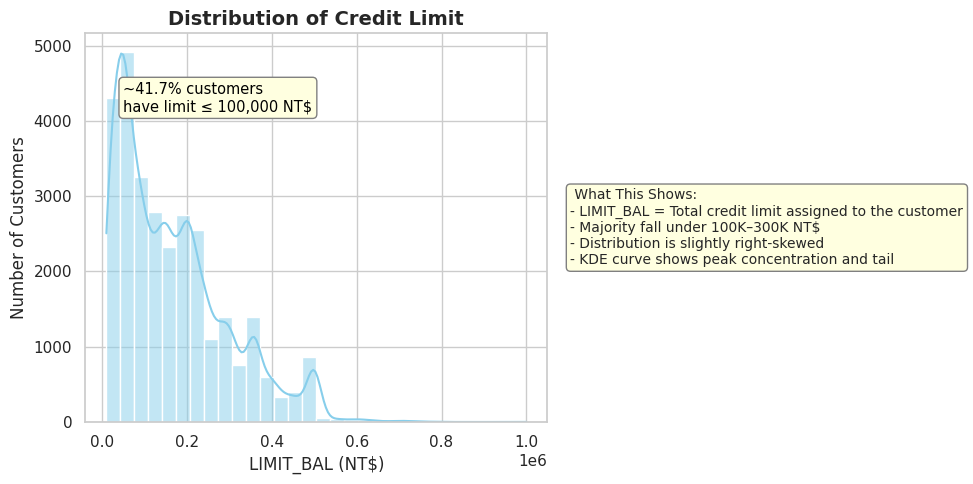

In [ ]:
print(" Histogram for: LIMIT_BAL (Credit Limit)")

import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['LIMIT_BAL'], kde=True, bins=30, color='skyblue', ax=ax)
ax.set_title("Distribution of Credit Limit", fontsize=14, fontweight='bold')
ax.set_xlabel("LIMIT_BAL (NT$)", fontsize=12)
ax.set_ylabel("Number of Customers", fontsize=12)

#  On-graph annotation: % of customers with credit limit ≤ 100,000
low_limit_pct = (df['LIMIT_BAL'] <= 100000).mean() * 100
ax.text(50000, ax.get_ylim()[1]*0.8,
        f"~{low_limit_pct:.1f}% customers\nhave limit ≤ 100,000 NT$",
        fontsize=10.5, color='black',
        bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))

explanation = (
    " What This Shows:\n"
    "- LIMIT_BAL = Total credit limit assigned to the customer\n"
    "- Majority fall under 100K–300K NT$\n"
    "- Distribution is slightly right-skewed\n"
    "- KDE curve shows peak concentration and tail"
)
ax.text(1.05, 0.5, explanation, transform=ax.transAxes,
        fontsize=10, va='center',
        bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))

# Adjust layout to fit side box
plt.subplots_adjust(right=0.8)
plt.tight_layout()
plt.show()

 Age Group Distribution of Customers


/tmp/ipython-input-2880835767.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values, palette='Greens', ax=ax)


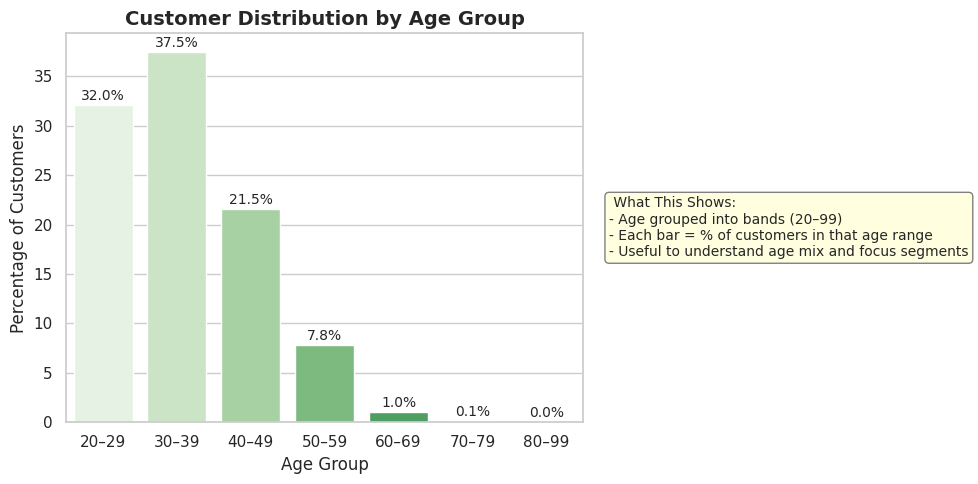

In [ ]:
print(" Age Group Distribution of Customers")

age_bins = [20, 30, 40, 50, 60, 70, 80, 100]
age_labels = ['20–29', '30–39', '40–49', '50–59', '60–69', '70–79', '80–99']

df['AGE_GROUP'] = pd.cut(df['AGE'], bins=age_bins, labels=age_labels, right=False)

age_counts = df['AGE_GROUP'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=age_counts.index, y=age_counts.values, palette='Greens', ax=ax)

ax.set_title("Customer Distribution by Age Group", fontsize=14, fontweight='bold')
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Percentage of Customers", fontsize=12)

for i, pct in enumerate(age_counts.values):
    ax.text(i, pct + 0.5, f"{pct:.1f}%", ha='center', fontsize=10)

# Explanation on side
explanation = (
    " What This Shows:\n"
    "- Age grouped into bands (20–99)\n"
    "- Each bar = % of customers in that age range\n"
    "- Useful to understand age mix and focus segments"
)

ax.text(1.05, 0.5, explanation, transform=ax.transAxes,
        fontsize=10, va='center',
        bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))

# Adjust layout
plt.subplots_adjust(right=0.75)
plt.tight_layout()
plt.show()

 Boxplot: Bill Statement Amounts (BILL_AMT1–6)


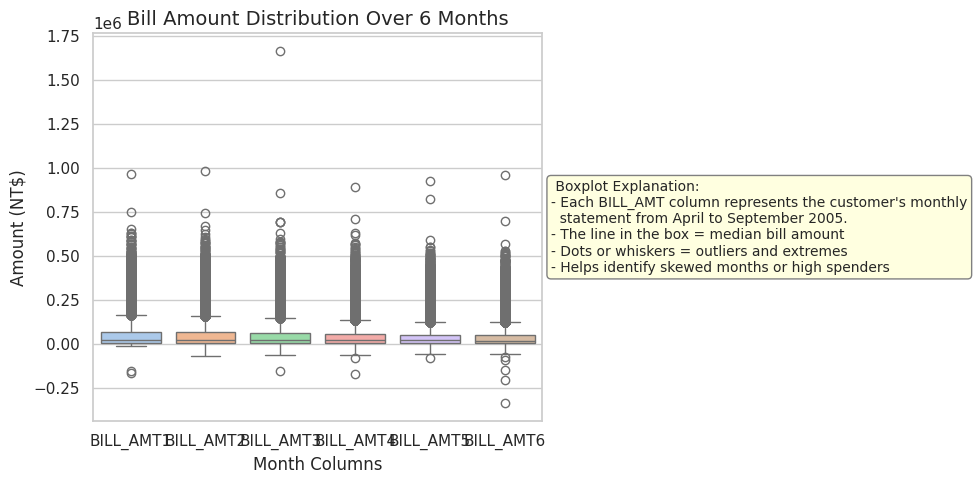

In [ ]:
print(" Boxplot: Bill Statement Amounts (BILL_AMT1–6)")

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df[[f'BILL_AMT{i}' for i in range(1, 7)]], palette='pastel', ax=ax)

ax.set_title("Bill Amount Distribution Over 6 Months", fontsize=14)
ax.set_xlabel("Month Columns")
ax.set_ylabel("Amount (NT$)")

explanation = (
    " Boxplot Explanation:\n"
    "- Each BILL_AMT column represents the customer's monthly\n"
    "  statement from April to September 2005.\n"
    "- The line in the box = median bill amount\n"
    "- Dots or whiskers = outliers and extremes\n"
    "- Helps identify skewed months or high spenders"
)

ax.text(1.02, 0.5, explanation, transform=ax.transAxes,
        fontsize=10, va='center', bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))

plt.tight_layout()
plt.show()

 Violin Plot: Payment Amounts (PAY_AMT1–6) with % Insight on Graph


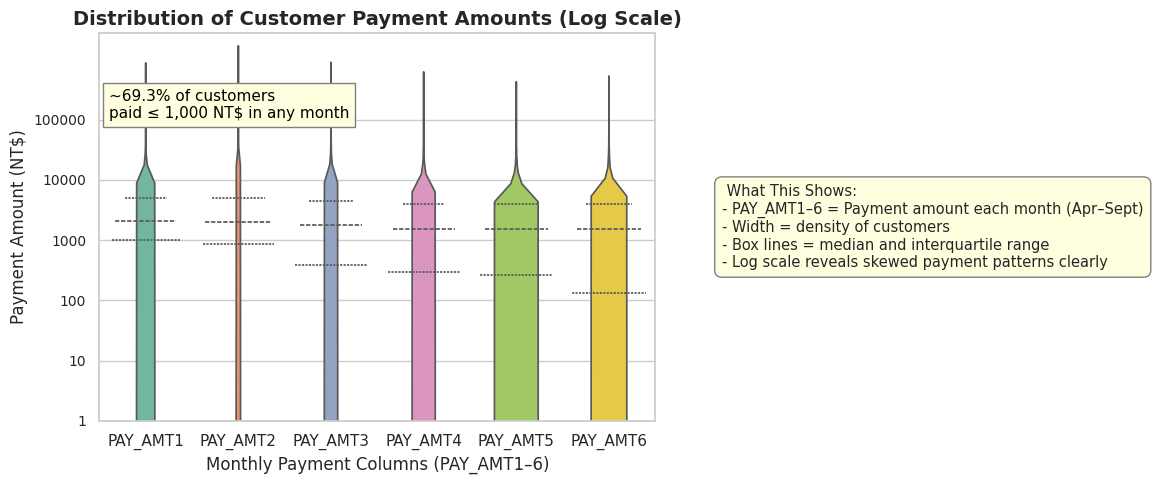

In [ ]:
print(" Violin Plot: Payment Amounts (PAY_AMT1–6) with % Insight on Graph")

import numpy as np
fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(
    data=df[[f'PAY_AMT{i}' for i in range(1, 7)]],
    palette='Set2',
    inner='quartile',
    cut=0,
    ax=ax
)

ax.set_title("Distribution of Customer Payment Amounts (Log Scale)", fontsize=14, fontweight='bold')
ax.set_xlabel("Monthly Payment Columns (PAY_AMT1–6)", fontsize=12)
ax.set_ylabel("Payment Amount (NT$)", fontsize=12)

ax.set_yscale('log')
ax.set_yticks([1, 10, 100, 1_000, 10_000, 100_000])
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.tick_params(axis='y', labelsize=10)

low_payment_pct = (df[[f'PAY_AMT{i}' for i in range(1, 7)]] <= 1000).any(axis=1).mean() * 100

ax.text(-0.4, 105000,
        f"~{low_payment_pct:.1f}% of customers\npaid ≤ 1,000 NT$ in any month",
        fontsize=11, color='black', bbox=dict(facecolor='lightyellow', edgecolor='gray'))

explanation = (
    " What This Shows:\n"
    "- PAY_AMT1–6 = Payment amount each month (Apr–Sept)\n"
    "- Width = density of customers\n"
    "- Box lines = median and interquartile range\n"
    "- Log scale reveals skewed payment patterns clearly"
)

ax.text(1.12, 0.5, explanation, transform=ax.transAxes,
        fontsize=10.5, va='center',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", edgecolor="gray"))

# Final layout
plt.subplots_adjust(right=0.8)
plt.tight_layout()
plt.show()

/tmp/ipython-input-2581691239.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='default', data=default_rate, palette='pastel', ax=ax)


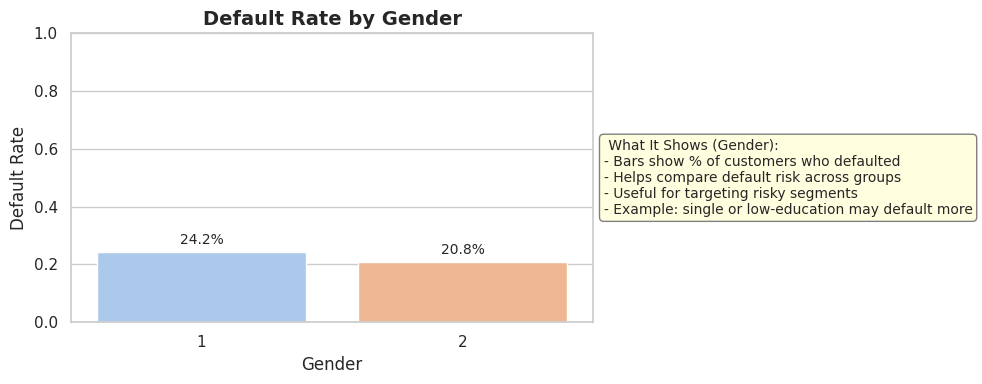

/tmp/ipython-input-2581691239.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='default', data=default_rate, palette='pastel', ax=ax)


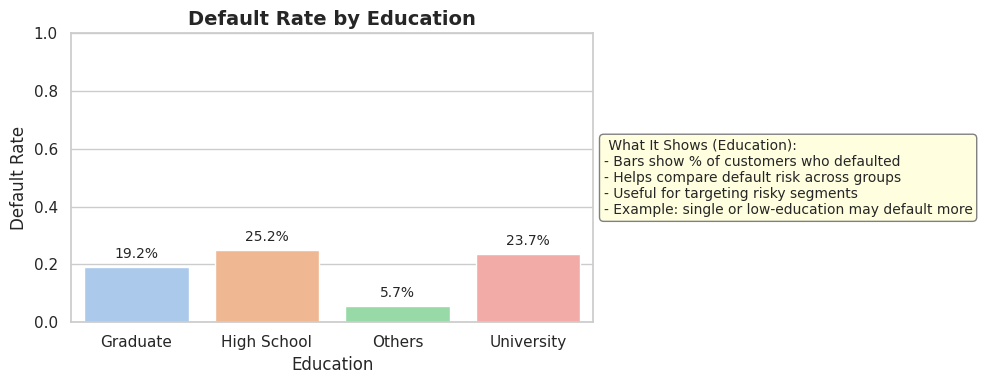

/tmp/ipython-input-2581691239.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='default', data=default_rate, palette='pastel', ax=ax)


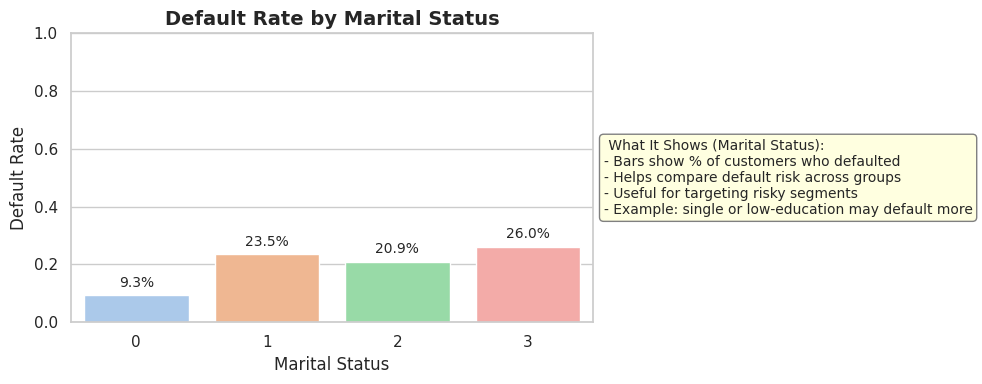

In [ ]:
cat_cols = ['SEX', 'EDUCATION_LAB', 'MARRIAGE']
titles = {'SEX': 'Gender', 'EDUCATION_LAB': 'Education', 'MARRIAGE': 'Marital Status'}

for col in cat_cols:
    fig, ax = plt.subplots(figsize=(10, 4))  # Wider for explanation

    # Calculate default rate by category
    default_rate = df.groupby(col)['default'].mean().reset_index()

    sns.barplot(x=col, y='default', data=default_rate, palette='pastel', ax=ax)
    ax.set_title(f"Default Rate by {titles.get(col, col)}", fontsize=14, fontweight='bold')
    ax.set_ylabel("Default Rate")
    ax.set_xlabel(titles.get(col, col))
    ax.set_ylim(0, 1)

    # Annotate % above bars
    for i, row in default_rate.iterrows():
        ax.text(i, row['default'] + 0.03, f"{row['default']*100:.1f}%", ha='center', fontsize=10)

    explanation = (
        f" What It Shows ({titles.get(col, col)}):\n"
        "- Bars show % of customers who defaulted\n"
        "- Helps compare default risk across groups\n"
        "- Useful for targeting risky segments\n"
        "- Example: single or low-education may default more"
    )
    ax.text(1.02, 0.5, explanation, transform=ax.transAxes,
            fontsize=10, va='center',
            bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))

    plt.subplots_adjust(right=0.72)
    plt.tight_layout()
    plt.show()

/tmp/ipython-input-271267838.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y=col, data=df, palette='pastel', ax=ax)
/tmp/ipython-input-271267838.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(y/1000)}K' for y in ax.get_yticks()])


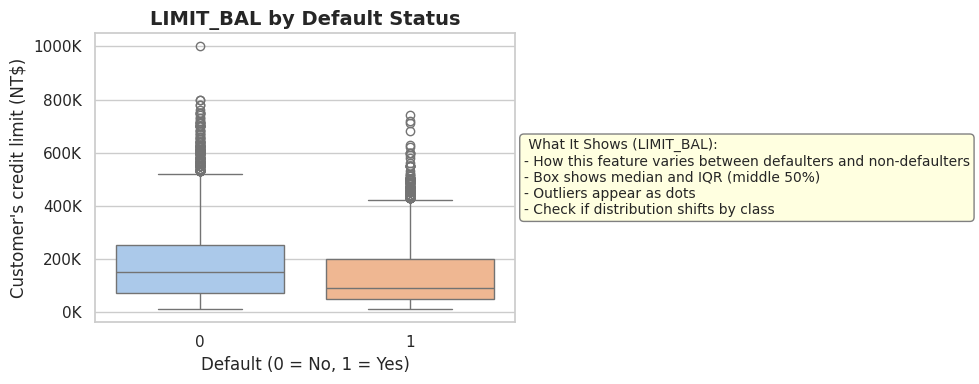

/tmp/ipython-input-271267838.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y=col, data=df, palette='pastel', ax=ax)


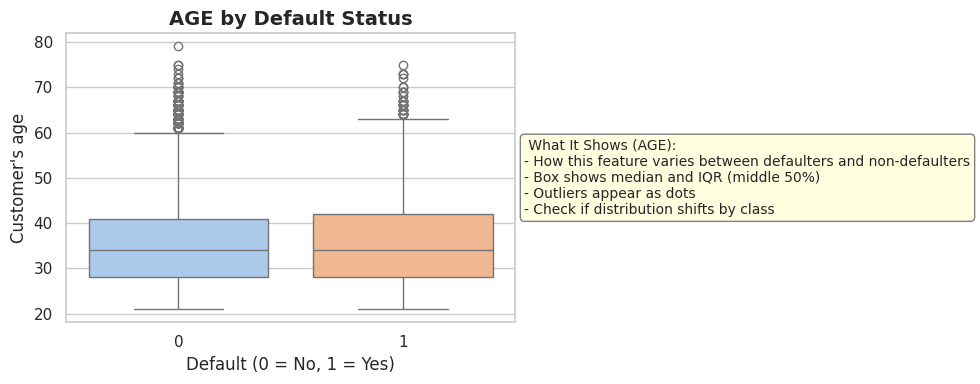

/tmp/ipython-input-271267838.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y=col, data=df, palette='pastel', ax=ax)
/tmp/ipython-input-271267838.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(y/1000)}K' for y in ax.get_yticks()])


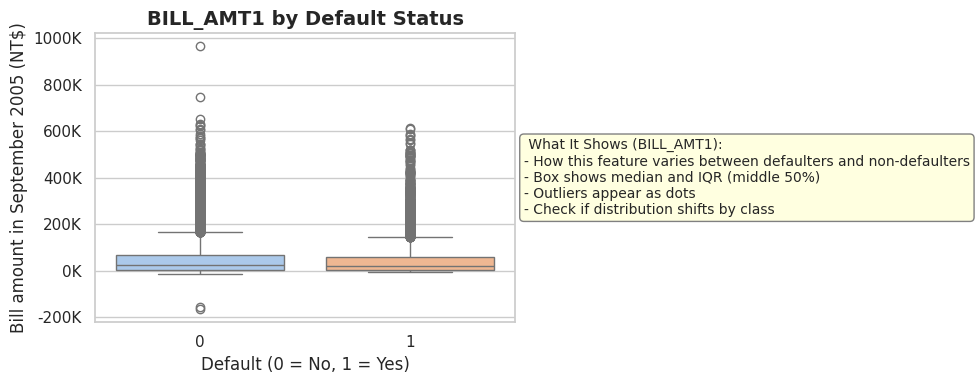

/tmp/ipython-input-271267838.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y=col, data=df, palette='pastel', ax=ax)
/tmp/ipython-input-271267838.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(y/1000)}K' for y in ax.get_yticks()])


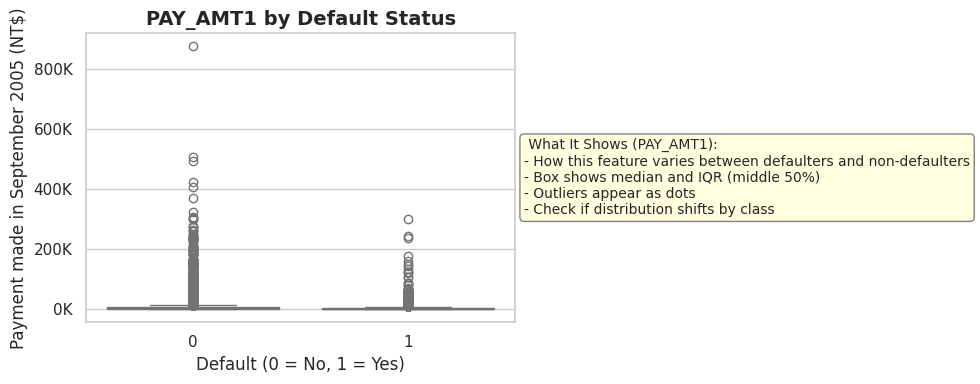

In [ ]:
num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']
descriptions = {
    'LIMIT_BAL': "Customer's credit limit (NT$)",
    'AGE': "Customer's age",
    'BILL_AMT1': "Bill amount in September 2005 (NT$)",
    'PAY_AMT1': "Payment made in September 2005 (NT$)"
}

for col in num_cols:
    fig, ax = plt.subplots(figsize=(10, 4))  # Wider for explanation
    sns.boxplot(x='default', y=col, data=df, palette='pastel', ax=ax)

    ax.set_title(f"{col} by Default Status", fontsize=14, fontweight='bold')
    ax.set_xlabel("Default (0 = No, 1 = Yes)", fontsize=12)
    ax.set_ylabel(descriptions.get(col, col), fontsize=12)

    if 'AMT' in col or 'LIMIT' in col:
        ax.set_yticklabels([f'{int(y/1000)}K' for y in ax.get_yticks()])

    explanation = (
        f" What It Shows ({col}):\n"
        "- How this feature varies between defaulters and non-defaulters\n"
        "- Box shows median and IQR (middle 50%)\n"
        "- Outliers appear as dots\n"
        "- Check if distribution shifts by class"
    )
    ax.text(1.02, 0.5, explanation, transform=ax.transAxes,
            fontsize=10, va='center',
            bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))

    plt.subplots_adjust(right=0.75)
    plt.tight_layout()
    plt.show()

 Violin Plot: Credit Limit (LIMIT_BAL) by Default Status


/tmp/ipython-input-510190118.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='default', y='LIMIT_BAL', palette='Set2', inner='quartile', ax=ax)


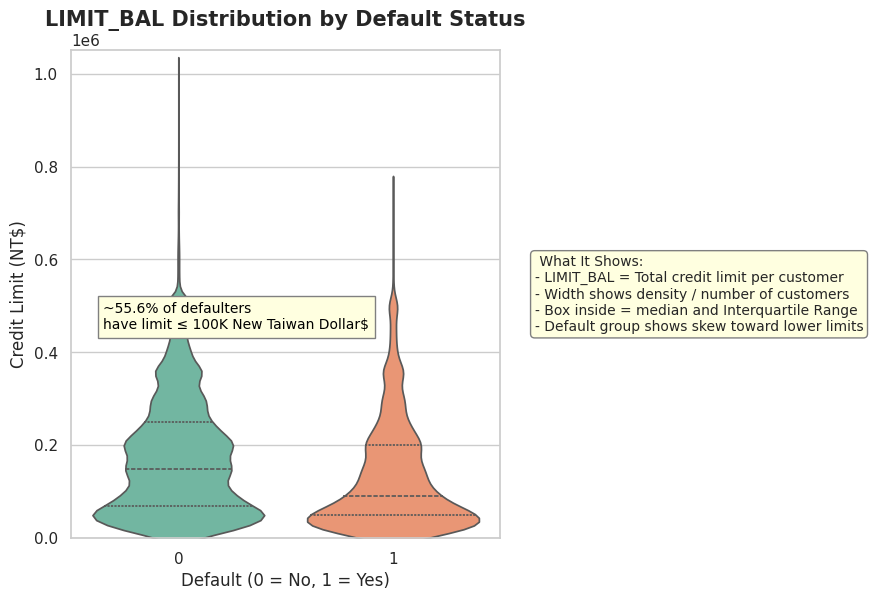

In [ ]:
print(" Violin Plot: Credit Limit (LIMIT_BAL) by Default Status")

fig, ax = plt.subplots(figsize=(9, 6))
sns.violinplot(data=df, x='default', y='LIMIT_BAL', palette='Set2', inner='quartile', ax=ax)

ax.set_title("LIMIT_BAL Distribution by Default Status", fontsize=15, fontweight='bold')
ax.set_xlabel("Default (0 = No, 1 = Yes)", fontsize=12)
ax.set_ylabel("Credit Limit (NT$)", fontsize=12)

ax.set_ylim(0, df['LIMIT_BAL'].max() * 1.05)

low_limit_pct = (df[df['default'] == 1]['LIMIT_BAL'] <= 100000).mean() * 100
ax.text(-0.35, 450000,
        f"~{low_limit_pct:.1f}% of defaulters\nhave limit ≤ 100K New Taiwan Dollar$",
        fontsize=10, color='black',
        bbox=dict(facecolor='lightyellow', edgecolor='gray'))

explanation = (
    " What It Shows:\n"
    "- LIMIT_BAL = Total credit limit per customer\n"
    "- Width shows density / number of customers\n"
    "- Box inside = median and Interquartile Range\n"
    "- Default group shows skew toward lower limits"
)

ax.text(1.08, 0.5, explanation, transform=ax.transAxes,
        fontsize=10, va='center',
        bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))

# Layout adjustments
plt.subplots_adjust(right=0.75)
plt.tight_layout()
plt.show()

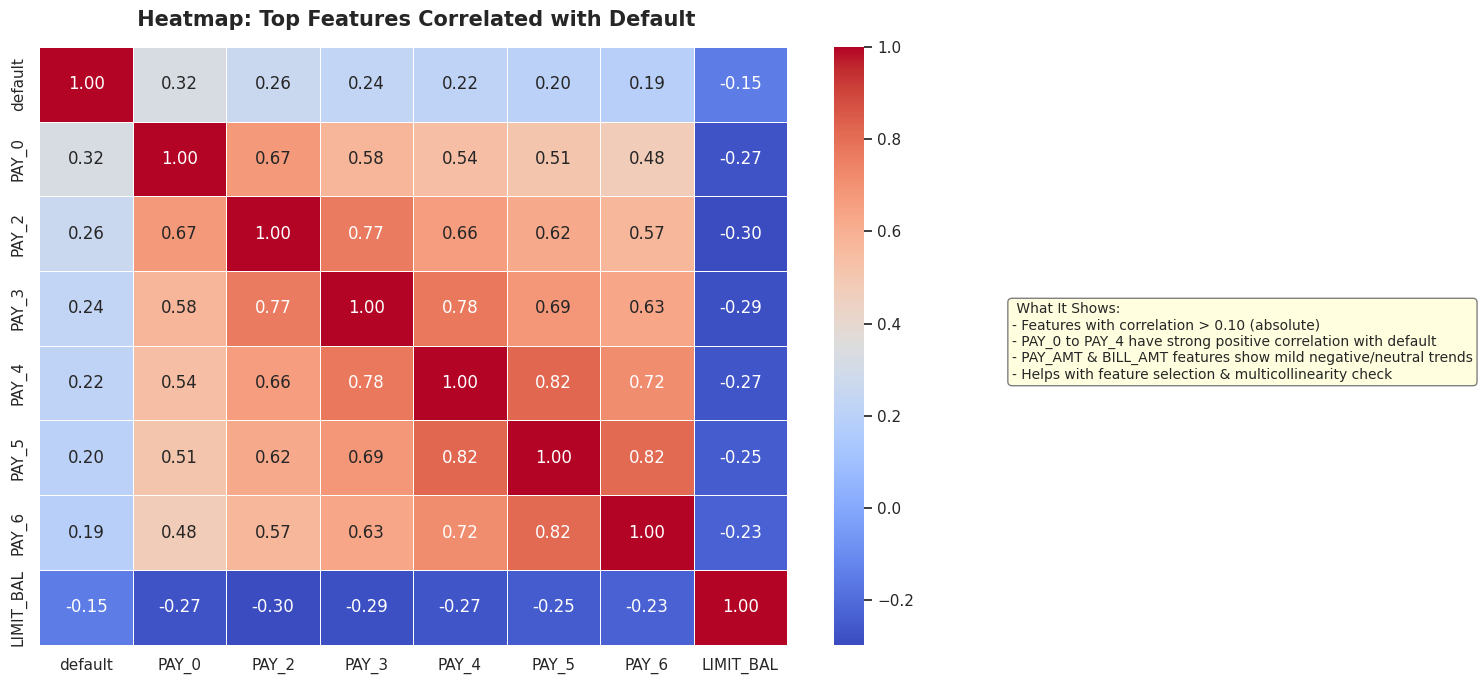

In [ ]:
# Get correlation with target
target_corr = corrMatrix['default'].abs().sort_values(ascending=False)

# Select top features (above threshold)
top_features = target_corr[target_corr > 0.1].index

# Plot
plt.figure(figsize=(10, 7))
ax = sns.heatmap(df[top_features].corr(numeric_only=True),
                 annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

# Heading
plt.title(" Heatmap: Top Features Correlated with Default", fontsize=15, fontweight='bold', pad=15)

# Explanation box
explanation = (
    " What It Shows:\n"
    "- Features with correlation > 0.10 (absolute)\n"
    "- PAY_0 to PAY_4 have strong positive correlation with default\n"
    "- PAY_AMT & BILL_AMT features show mild negative/neutral trends\n"
    "- Helps with feature selection & multicollinearity check"
)
# Add text box on side
plt.gcf().text(1.02, 0.5, explanation, fontsize=10, va='center',
               bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))

# Layout fix
plt.subplots_adjust(right=0.75)
plt.tight_layout()
plt.show()

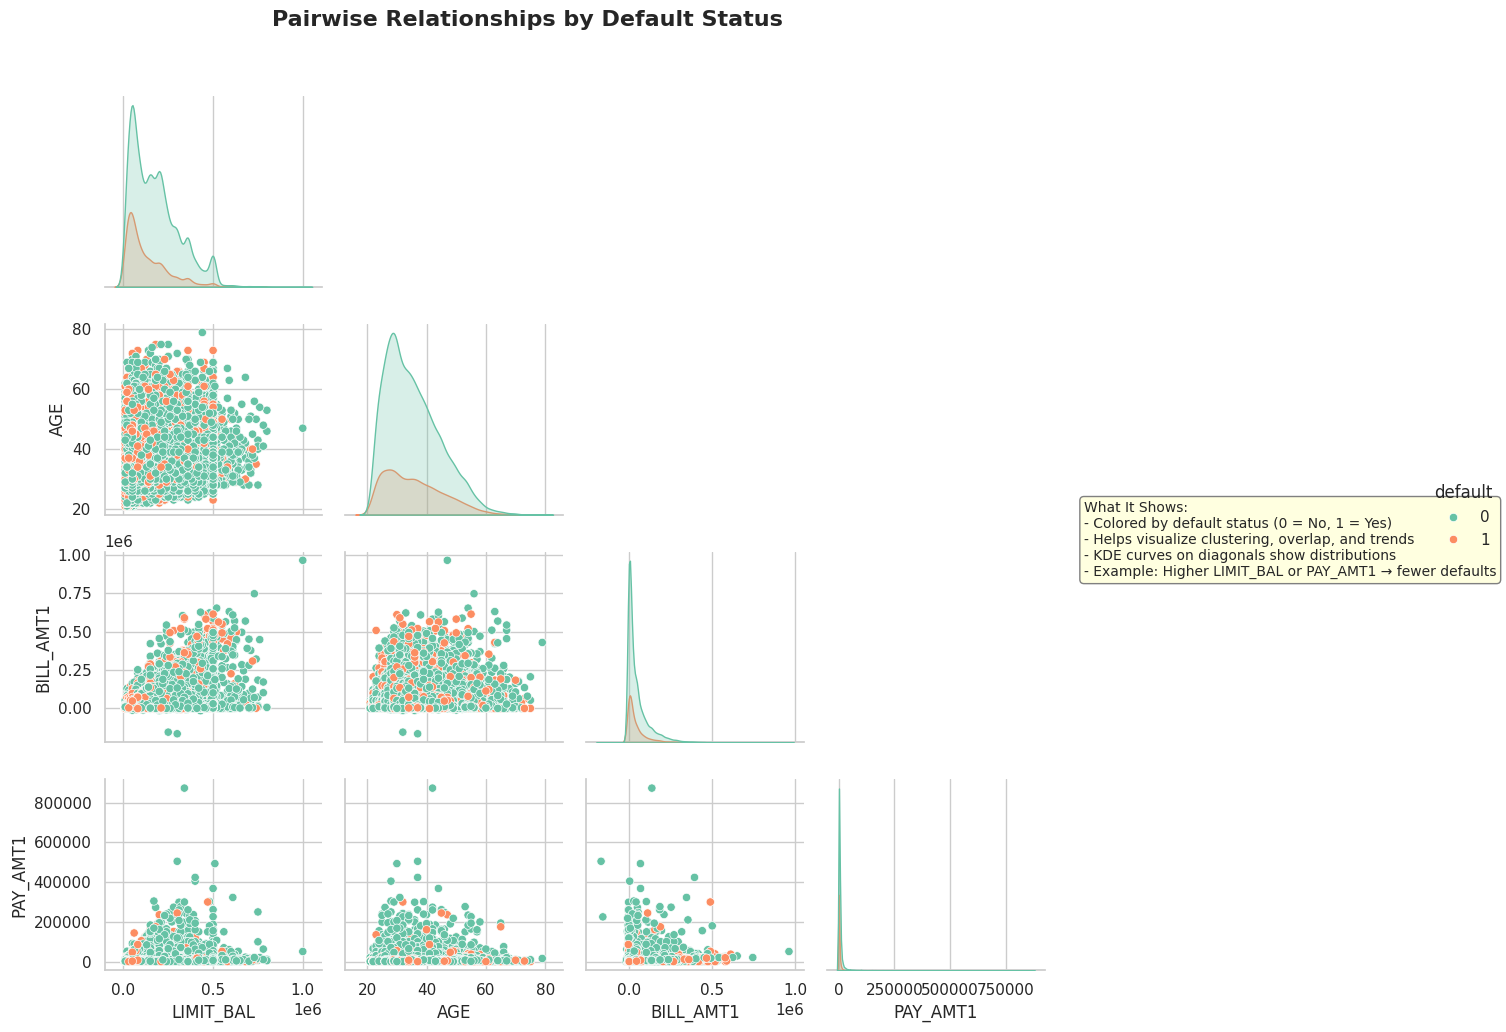

In [ ]:
# Feature subset for clarity
features = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'default']
pair_df = df[features]

#  Style
sns.set_style("whitegrid")

#  Pairplot
plot = sns.pairplot(pair_df, hue="default", palette='Set2', corner=True, diag_kind='kde')
plot.fig.suptitle("Pairwise Relationships by Default Status", fontsize=16, fontweight='bold', y=1.03)

#  Explanation box (as a caption using fig.text)
explanation = (
    "What It Shows:\n"
    "- Colored by default status (0 = No, 1 = Yes)\n"
    "- Helps visualize clustering, overlap, and trends\n"
    "- KDE curves on diagonals show distributions\n"
    "- Example: Higher LIMIT_BAL or PAY_AMT1 → fewer defaults"
)

# Add explanation to the side
plot.fig.text(1.02, 0.5, explanation, fontsize=10, va='center',
              bbox=dict(boxstyle="round", facecolor="lightyellow", edgecolor="gray"))

# Layout fix
plt.subplots_adjust(right=0.75)
plt.tight_layout()
plt.show()

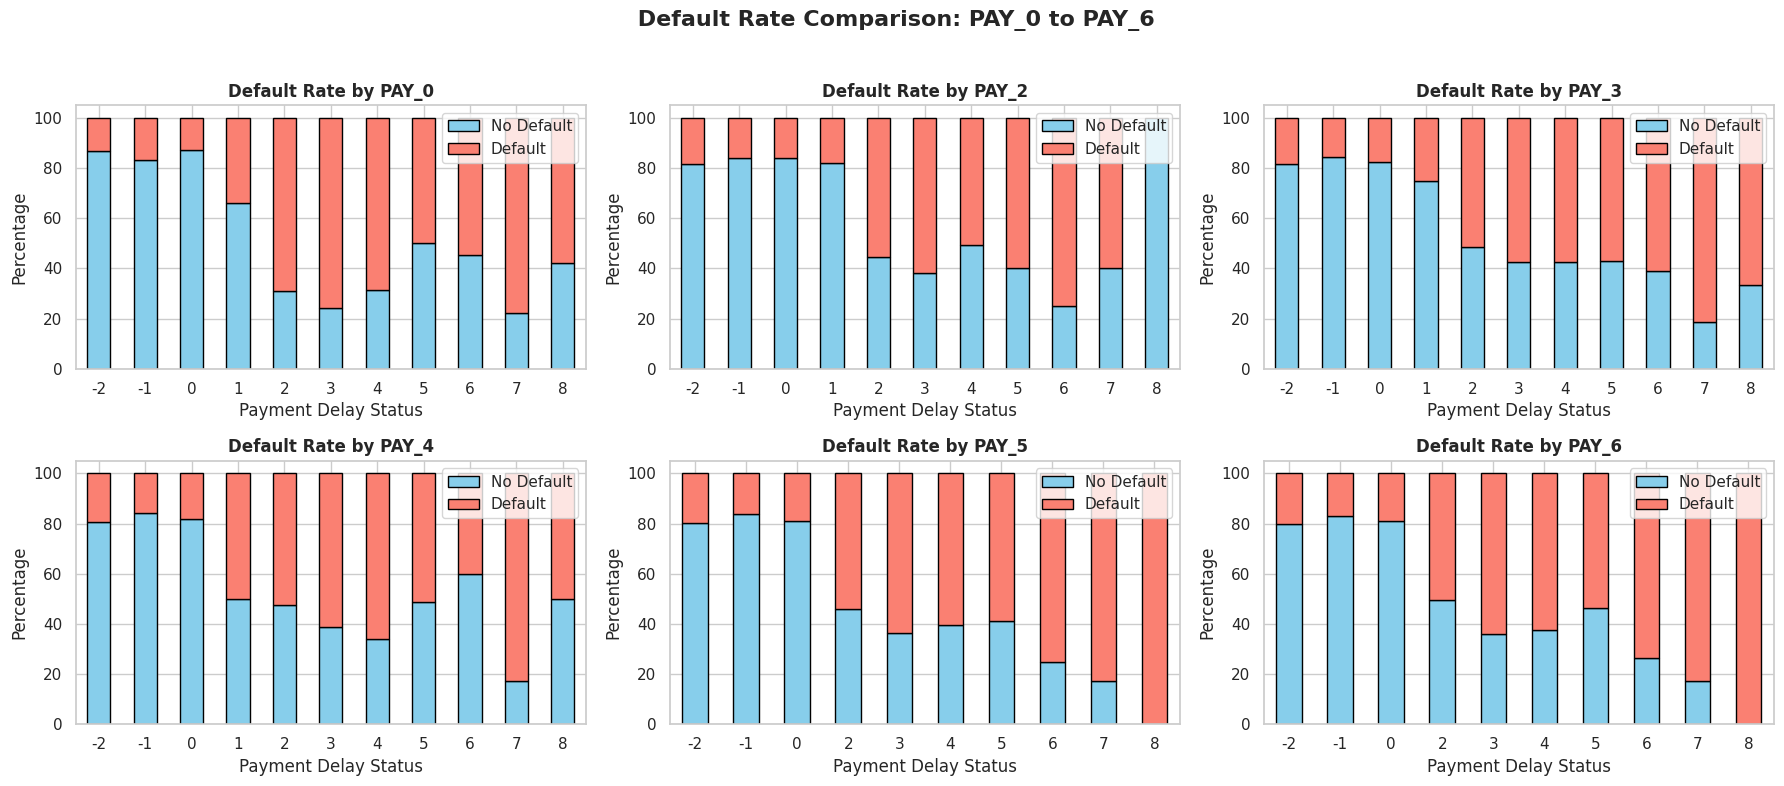

In [ ]:
import matplotlib.pyplot as plt

#  Only include delay status columns (not continuous PAY_AMT)
pay_cols = [col for col in df.columns if col.startswith('PAY_') and not col.startswith('PAY_AMT')]

#  Create subplots layout
num_cols = len(pay_cols)
cols = 3
rows = (num_cols + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

# Loop through and plot each PAY_* column
for idx, col in enumerate(pay_cols):
    try:
        delay_df = df.groupby(col)['default'].value_counts(normalize=True).unstack().fillna(0) * 100
        delay_df.columns = ['No Default', 'Default']
        delay_df[['No Default', 'Default']].plot(
            kind='bar',
            stacked=True,
            color=['skyblue', 'salmon'],
            edgecolor='black',
            ax=axes[idx]
        )
        axes[idx].set_title(f"Default Rate by {col}", fontsize=12, fontweight='bold')
        axes[idx].set_ylabel("Percentage")
        axes[idx].set_xlabel("Payment Delay Status")
        axes[idx].set_xticklabels(delay_df.index.astype(str), rotation=0)
    except Exception as e:
        print(f"Skipped {col} due to error: {e}")

#  Remove unused subplots
for i in range(len(pay_cols), len(axes)):
    fig.delaxes(axes[i])

#  Final title and layout
plt.suptitle(" Default Rate Comparison: PAY_0 to PAY_6", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

/tmp/ipython-input-3731251620.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='default', y=col, palette='Set2', ax=axes[idx], inner='quartile')
/tmp/ipython-input-3731251620.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='default', y=col, palette='Set2', ax=axes[idx], inner='quartile')
/tmp/ipython-input-3731251620.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='default', y=col, palette='Set2', ax=axes[idx], inner='quartile')
/tmp/ipython-input-3731251620.py:9: FutureWarning: 

Passing 

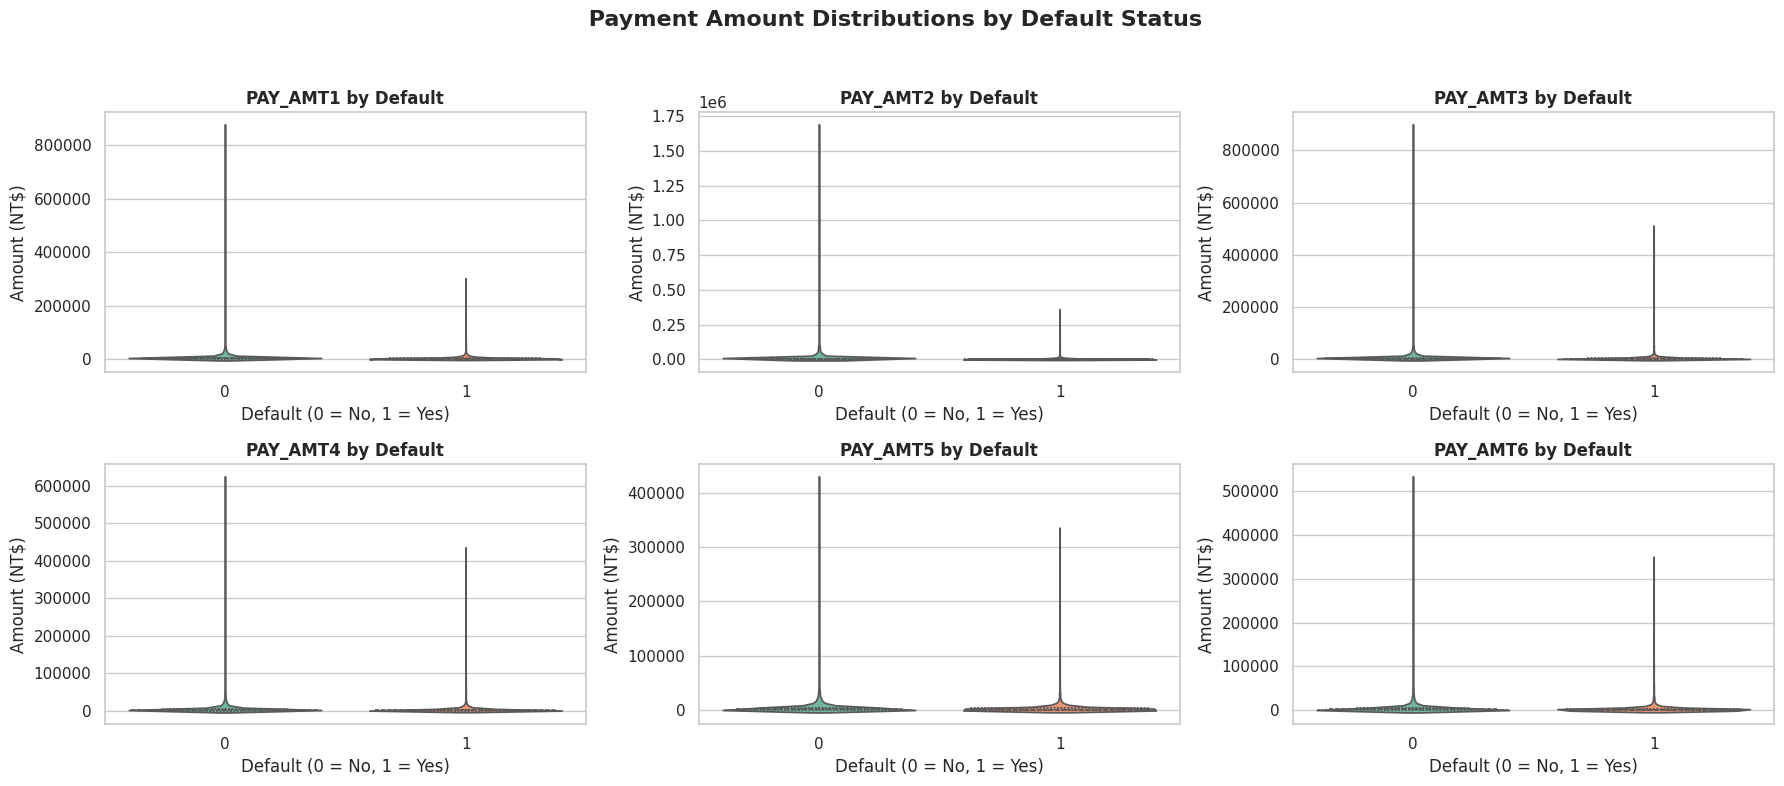

In [ ]:
pay_amt_cols = [col for col in df.columns if col.startswith('PAY_AMT')]
[68]

#  Create subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 8))
axes = axes.flatten()

for idx, col in enumerate(pay_amt_cols):
    sns.violinplot(data=df, x='default', y=col, palette='Set2', ax=axes[idx], inner='quartile')
    axes[idx].set_title(f"{col} by Default", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Default (0 = No, 1 = Yes)")
    axes[idx].set_ylabel("Amount (NT$)")

plt.suptitle(" Payment Amount Distributions by Default Status", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

 Variance Inflation Factor (VIF) Table
      Feature        VIF
0       const  63.714698
1   BILL_AMT2  25.850577
2   BILL_AMT5  24.984018
3   BILL_AMT3  21.764110
4   BILL_AMT4  20.336194
5   BILL_AMT6  15.017505
6   BILL_AMT1  14.025676
7       PAY_5   4.711785
8       PAY_4   4.275609
9       PAY_3   3.647696
10      PAY_6   3.247858
11      PAY_2   3.170421
12   PAY_AMT2   2.236977
13      PAY_0   1.927697
14   PAY_AMT3   1.756878
15   PAY_AMT1   1.707699
16   PAY_AMT5   1.687635
17   PAY_AMT4   1.648563
18  LIMIT_BAL   1.558756
19        AGE   1.274846
20   MARRIAGE   1.229881
21   PAY_AMT6   1.169891
22  EDUCATION   1.125630
23        SEX   1.024063


/tmp/ipython-input-825199646.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vif_df[1:], x='VIF', y='Feature', palette='crest')  # Skip the constant


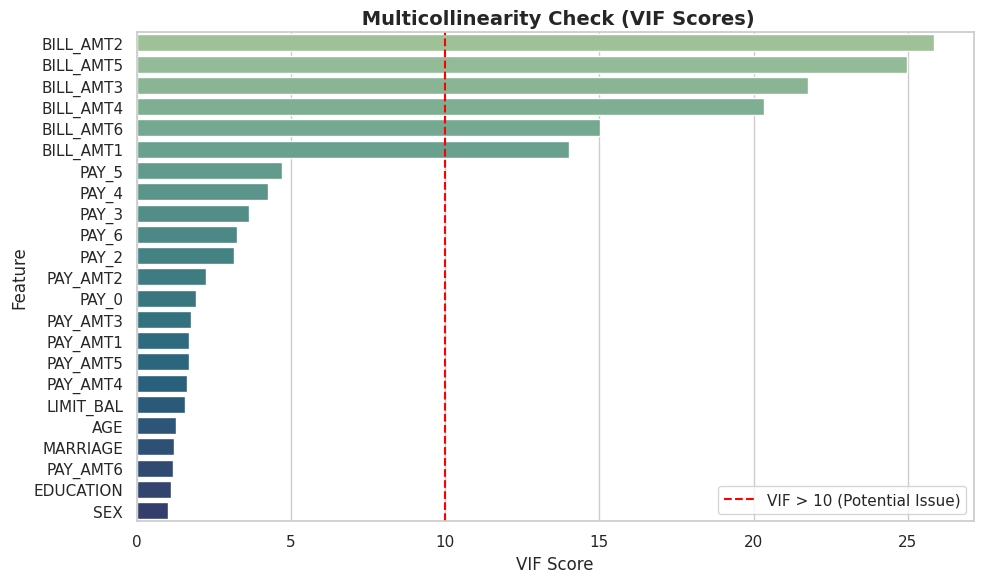

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical features (excluding target and ID)
numeric_features = df.select_dtypes(include='number').drop(columns=['default'])

# Add constant (intercept)
X = add_constant(numeric_features)

#  Calculate VIF
vif_df = pd.DataFrame()
vif_df["Feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df = vif_df.sort_values(by="VIF", ascending=False).reset_index(drop=True)

# Show VIF table
print(" Variance Inflation Factor (VIF) Table")
print(vif_df)

# Visualize VIF
plt.figure(figsize=(10, 6))
sns.barplot(data=vif_df[1:], x='VIF', y='Feature', palette='crest')  # Skip the constant
plt.axvline(x=10, color='red', linestyle='--', label='VIF > 10 (Potential Issue)')
plt.title(" Multicollinearity Check (VIF Scores)", fontsize=14, fontweight='bold')
plt.xlabel("VIF Score")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df['default'].value_counts()


,count
default,
0,23335
1,6630


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numeric_cols)


Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='object')


In [ ]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"{col}: {outliers} outliers")


LIMIT_BAL: 167 outliers
SEX: 0 outliers
EDUCATION: 454 outliers
MARRIAGE: 0 outliers
AGE: 272 outliers
PAY_0: 3129 outliers
PAY_2: 4409 outliers
PAY_3: 4208 outliers
PAY_4: 3507 outliers
PAY_5: 2967 outliers
PAY_6: 3078 outliers
BILL_AMT1: 2386 outliers
BILL_AMT2: 2390 outliers
BILL_AMT3: 2469 outliers
BILL_AMT4: 2616 outliers
BILL_AMT5: 2724 outliers
BILL_AMT6: 2688 outliers
PAY_AMT1: 2742 outliers
PAY_AMT2: 2723 outliers
PAY_AMT3: 2596 outliers
PAY_AMT4: 2993 outliers
PAY_AMT5: 2944 outliers
PAY_AMT6: 2960 outliers
default: 6630 outliers


In [ ]:
def winsorize_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# Apply to all relevant numeric columns except the target
feature_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('default')

for col in feature_cols:
    df = winsorize_iqr(df, col)


**recount outliers after winsorization**

In [ ]:
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((series < lower_bound) | (series > upper_bound)).sum()

# Recheck outliers in numeric features
outlier_counts_after = df[feature_cols].apply(count_outliers_iqr)
print(outlier_counts_after.sort_values(ascending=False))


LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
dtype: int64


In [ ]:
df[feature_cols].describe().T[['min', 'max']]


,min,max
LIMIT_BAL,10000.0,525000.0
SEX,1.0,2.0
EDUCATION,0.0,3.5
MARRIAGE,0.0,3.0
AGE,21.0,60.5
PAY_0,-2.0,1.5
PAY_2,-2.0,1.5
PAY_3,-2.0,1.5
PAY_4,-2.0,1.5
PAY_5,-2.0,1.5


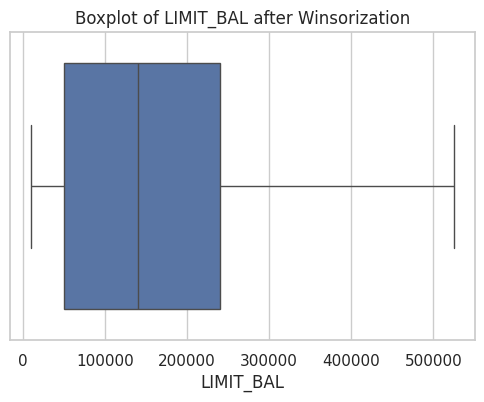

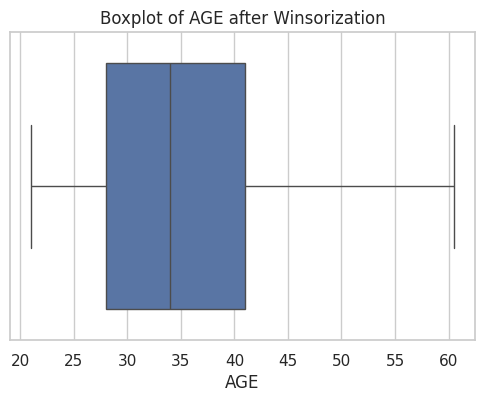

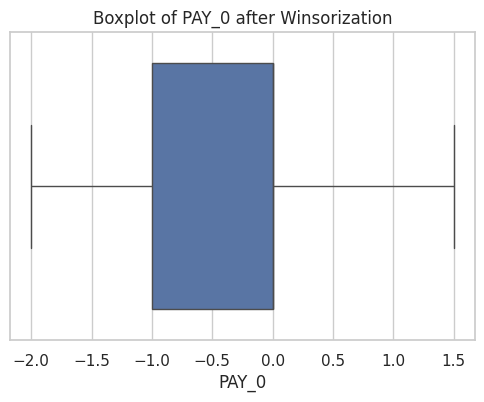

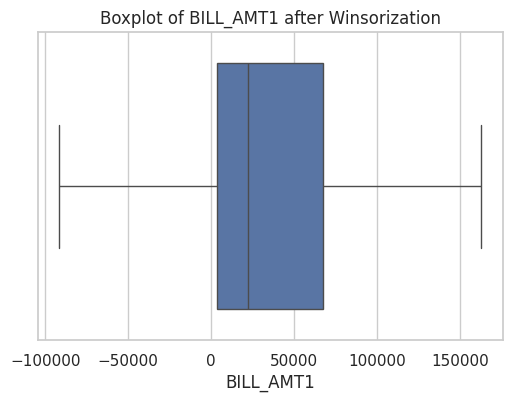

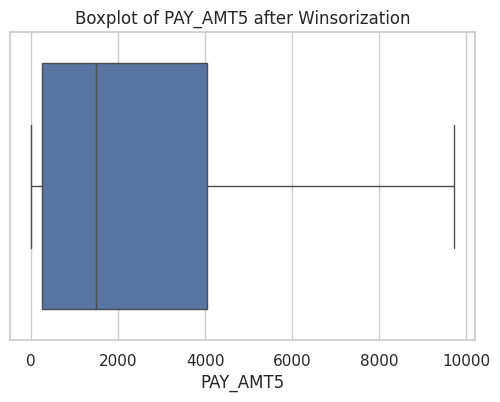

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplots for a few features after winsorization
cols_to_plot = ['LIMIT_BAL', 'AGE', 'PAY_0', 'BILL_AMT1', 'PAY_AMT5']

for col in cols_to_plot:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} after Winsorization')
    plt.show()


In [ ]:
# Step 3: One-hot encode categorical variables
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']

# One-hot encode and drop the first category to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Check the result
print(df_encoded.head())
print(f"New shape after encoding: {df_encoded.shape}")


   LIMIT_BAL   AGE  PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6  BILL_AMT1  \
0      20000  24.0    1.5    1.5   -1.0   -1.0   -2.0   -2.0     3913.0   
1     120000  26.0   -1.0    1.5    0.0    0.0    0.0    1.5     2682.0   
2      90000  34.0    0.0    0.0    0.0    0.0    0.0    0.0    29239.0   
3      50000  37.0    0.0    0.0    0.0    0.0    0.0    0.0    46990.0   
4      50000  57.0   -1.0    0.0   -1.0    0.0    0.0    0.0     8617.0   

   BILL_AMT2  ...  EDUCATION_LAB  AGE_GROUP  SEX_2  EDUCATION_1.0  \
0     3102.0  ...     University      20–29   True          False   
1     1725.0  ...     University      20–29   True          False   
2    14027.0  ...     University      30–39   True          False   
3    48233.0  ...     University      30–39   True          False   
4     5670.0  ...     University      50–59  False          False   

   EDUCATION_2.0  EDUCATION_3.0  EDUCATION_3.5  MARRIAGE_1  MARRIAGE_2  \
0           True          False          False        True  

In [ ]:
from sklearn.preprocessing import StandardScaler

# Make a copy to preserve encoded data
df_scaled = df_encoded.copy()

# Identify numerical columns (excluding target and encoded bools/objects)
numeric_cols = df_scaled.select_dtypes(include=['int64', 'float64']).drop(columns=['default']).columns

# Initialize scaler
scaler = StandardScaler()

# Fit and transform numeric columns
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

# Check the output
print(df_scaled[numeric_cols].head())


   LIMIT_BAL       AGE     PAY_0    PAY_2     PAY_3     PAY_4     PAY_5  \
0  -1.147654 -1.257438  1.675581  1.74682 -0.746245 -0.720412 -1.755870   
1  -0.366536 -1.037834 -0.952106  1.74682  0.259342  0.312046  0.356595   
2  -0.600871 -0.159420  0.098969  0.23272  0.259342  0.312046  0.356595   
3  -0.913318  0.169985  0.098969  0.23272  0.259342  0.312046  0.356595   
4  -0.913318  2.366019 -0.952106  0.23272 -0.746245  0.312046  0.356595   

      PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  \
0 -1.688618  -0.787656  -0.798141  -0.845320  -0.855484  -0.846695  -0.828540   
1  1.919662  -0.811620  -0.826064  -0.802653  -0.779026  -0.760155  -0.745773   
2  0.373257  -0.294639  -0.576601  -0.569793  -0.520605  -0.472279  -0.433893   
3  0.373257   0.050917   0.117037   0.195176  -0.193857  -0.121332  -0.078611   
4  0.373257  -0.696084  -0.746067  -0.092897  -0.366169  -0.367127  -0.342978   

   PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6 

**Final preprocessing and train-test split**

In [ ]:
# Use df directly to select features and target
X = df.drop(columns=['default'])  # drop the target column to get features
y = df['default']                 # target variable


In [ ]:
print(type(df))
print(df.head())


<class 'pandas.core.frame.DataFrame'>
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE   AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0      20000    2        2.0         1  24.0    1.5    1.5   -1.0   -1.0   
1     120000    2        2.0         2  26.0   -1.0    1.5    0.0    0.0   
2      90000    2        2.0         2  34.0    0.0    0.0    0.0    0.0   
3      50000    2        2.0         1  37.0    0.0    0.0    0.0    0.0   
4      50000    1        2.0         1  57.0   -1.0    0.0   -1.0    0.0   

   PAY_5  ...  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  \
0   -2.0  ...         0       689         0         0       0.0       0.0   
1    0.0  ...         0      1000      1000      1000       0.0    2000.0   
2    0.0  ...      1518      1500      1000      1000    1000.0    5000.0   
3    0.0  ...      2000      2019      1200      1100    1069.0    1000.0   
4    0.0  ...      2000     11225     10000      9000     689.0     679.0   

   default  default_label  EDUCATION_LAB  

In [ ]:
print(df['default'].value_counts(dropna=False))


default
0    23335
1     6630
Name: count, dtype: int64


In [ ]:
# Map 'Yes' -> 1, 'No' -> 0 in default_label to create default
df['default'] = df['default_label'].map({'Yes': 1, 'No': 0})

# Check if default is correctly created
print(df['default'].value_counts(dropna=False))


default
0    23335
1     6630
Name: count, dtype: int64


In [ ]:
# Drop target and non-numeric/categorical columns that we won't use directly (for now)
X = df.drop(columns=['default', 'default_label', 'EDUCATION_LAB', 'AGE_GROUP'])

# Target variable
y = df['default']

# Check shapes and first few rows
print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())
print(y.value_counts())


X shape: (29965, 23)
y shape: (29965,)
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE   AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0      20000    2        2.0         1  24.0    1.5    1.5   -1.0   -1.0   
1     120000    2        2.0         2  26.0   -1.0    1.5    0.0    0.0   
2      90000    2        2.0         2  34.0    0.0    0.0    0.0    0.0   
3      50000    2        2.0         1  37.0    0.0    0.0    0.0    0.0   
4      50000    1        2.0         1  57.0   -1.0    0.0   -1.0    0.0   

   PAY_5  ...  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  \
0   -2.0  ...        689        0.0          0          0         0       689   
1    0.0  ...       2682     3272.0       3455       3261         0      1000   
2    0.0  ...      13559    14331.0      14948      15549      1518      1500   
3    0.0  ...      49291    28314.0      28959      29547      2000      2019   
4    0.0  ...      35835    20940.0      19146      19131      2000     11225   

   PAY_AMT3  PAY_

In [ ]:
print(X.select_dtypes(include=['object', 'category']).columns)


Index([], dtype='object')


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled features shape:", X_scaled.shape)


Scaled features shape: (29965, 23)


In [ ]:
# Initialize results list and helper function
results = []

def append_results(results_list, model_name, accuracy, precision, recall, f1):
    results_list.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

**Logistic Regression**

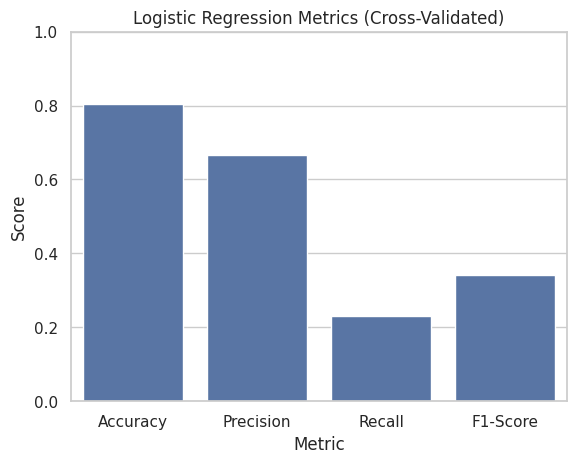

      Metric     Score
0   Accuracy  0.804105
1  Precision  0.665650
2     Recall  0.230317
3   F1-Score  0.342223


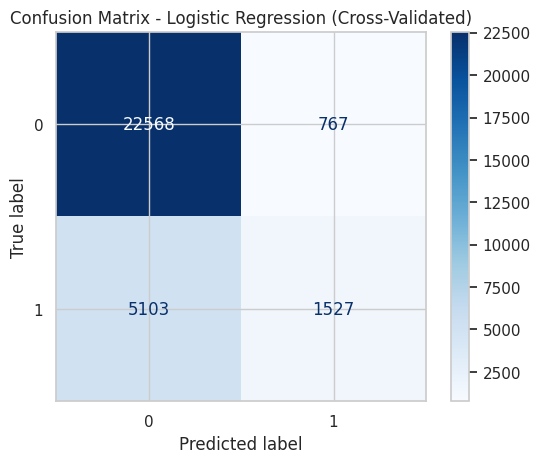

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize model
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Set up stratified k-fold with 5 splits
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validated predicted labels (no separate test set here)
y_pred = cross_val_predict(logreg, X_scaled, y, cv=skf)

# Calculate metrics using true labels and cross-validated predictions
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

# Create DataFrame for metrics
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1]
})

# Plot metrics
sns.barplot(x='Metric', y='Score', data=metrics_df)
plt.ylim(0, 1)
plt.title('Logistic Regression Metrics (Cross-Validated)')
plt.show()

# Print metrics table
print(metrics_df)

# Append results to your results list (make sure 'results = []' was defined earlier)
append_results(results, "Logistic Regression", accuracy, precision, recall, f1)

# Confusion matrix plot
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression (Cross-Validated)")
plt.show()


**True Negatives (TN)** = 22,568 — correctly predicted non-defaults


**False Positives (FP)** = 767 — non-defaults incorrectly predicted as defaults


**False Negatives (FN)** = 5,103 — defaults incorrectly predicted as non-defaults (missed defaults)


**True Positives (TP)** = 1,527 — correctly predicted defaults


The model is very good at identifying non-defaults but misses quite a few actual defaults (high FN). That aligns with the earlier recall score being low (~0.23), meaning the model isn’t catching many of the defaults.

**KNN**

Accuracy: 0.7895
Precision: 0.5392
Recall: 0.3339
F1 Score: 0.4124


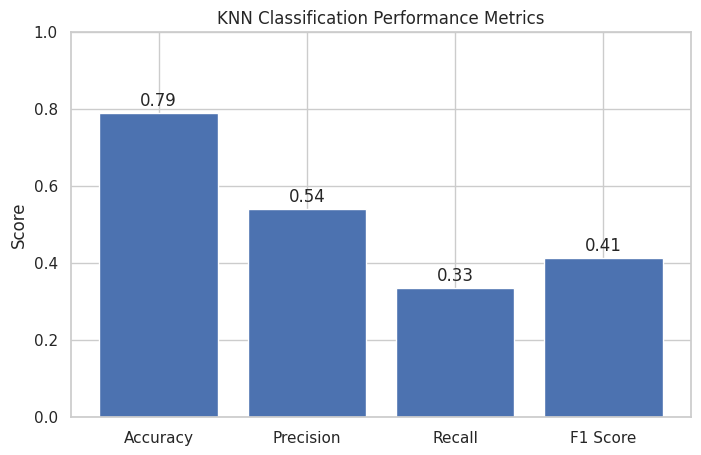

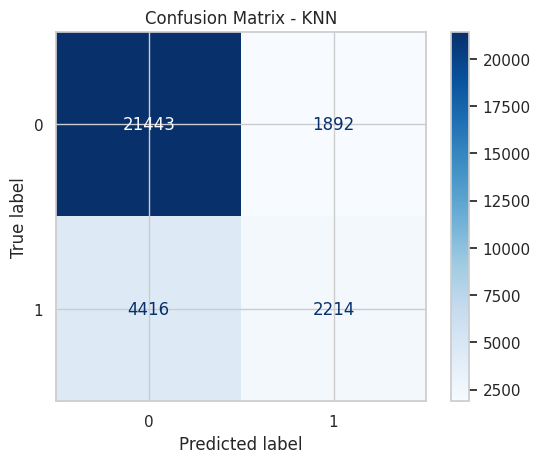

Confusion Matrix (KNN):
 [[21443  1892]
 [ 4416  2214]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt

# Initialize the model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Cross-validated predictions
y_pred_knn = cross_val_predict(knn_model, X_scaled, y, cv=5)

# Compute metrics
accuracy_knn = accuracy_score(y, y_pred_knn)
precision_knn = precision_score(y, y_pred_knn)
recall_knn = recall_score(y, y_pred_knn)
f1_knn = f1_score(y, y_pred_knn)

# Append results for summary table
append_results(results, "KNN", accuracy_knn, precision_knn, recall_knn, f1_knn)

# Display numeric results
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1 Score: {f1_knn:.4f}")

# Plot bar chart with actual computed metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy_knn, precision_knn, recall_knn, f1_knn]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, scores)
plt.ylim(0, 1)
plt.title("KNN Classification Performance Metrics")
plt.ylabel("Score")

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 0.02, f'{yval:.2f}', ha='center')

plt.show()

# Confusion matrix and plot
cm_knn = confusion_matrix(y, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=[0, 1])
disp_knn.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - KNN")
plt.show()

print("Confusion Matrix (KNN):\n", cm_knn)


**True Negatives (TN) = 21,443**

→ These are clients who didn’t default, and the model correctly predicted that.

**False Positives (FP) = 1,892**

→ These are clients who didn’t default, but the model wrongly predicted they would.
(This could lead to denying credit to good customers.)

**False Negatives (FN) = 4,416**

→ These are clients who did default, but the model failed to catch them.
This is a serious issue for banks — giving credit to risky clients.

**True Positives (TP) = 2,214**

→ These are clients who did default, and the model correctly identified them

High TN and decent TP —

the model is relatively good at identifying non-defaulters.

But high FN (4,416) -

it misses a lot of actual defaulters, which leads to low recall.

The recall score (≈ 33%) -

confirms this — it only identifies 1 in 3 actual defaulters.

**Decision Tree**

In [ ]:
from sklearn.model_selection import train_test_split

# Train-Test Split
# Already have X_scaled and y
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("y_test distribution:\n", y_test.value_counts())


X_train shape: (23972, 23)
X_test shape: (5993, 23)
y_train distribution:
 default
0    18668
1     5304
Name: count, dtype: int64
y_test distribution:
 default
0    4667
1    1326
Name: count, dtype: int64


Accuracy: 0.7265
Precision: 0.3858
Recall: 0.3989
F1 Score: 0.3923


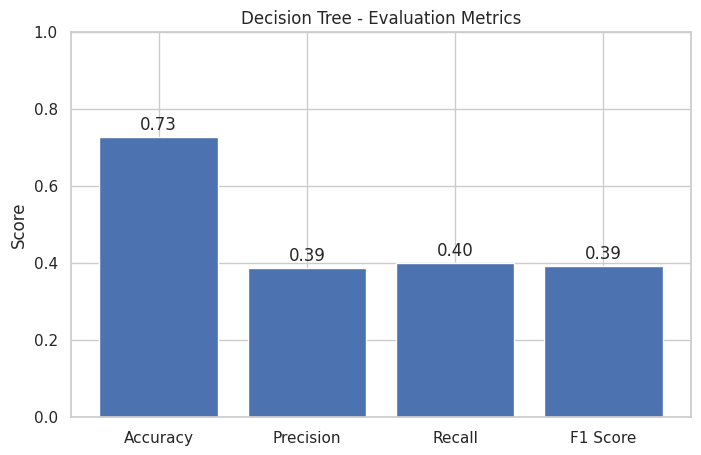

Confusion Matrix (Decision Tree):
 [[3825  842]
 [ 797  529]]


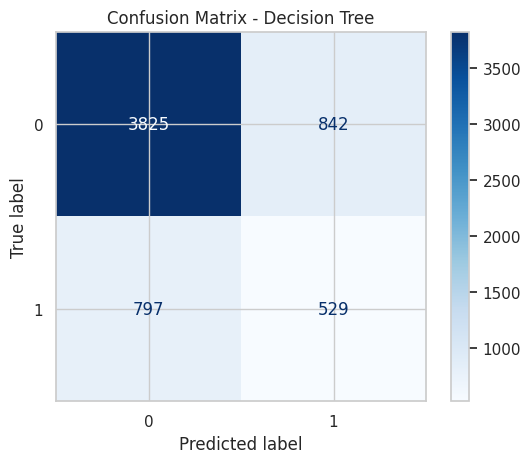

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize model
dtree = DecisionTreeClassifier(random_state=42)

# Fit model on all data (or you can use cross_val_predict if you want consistent CV)
dtree.fit(X_train, y_train)

# Predict on test set
y_pred_dtree = dtree.predict(X_test)

# Calculate metrics
accuracy_dt = accuracy_score(y_test, y_pred_dtree)
precision_dt = precision_score(y_test, y_pred_dtree)
recall_dt = recall_score(y_test, y_pred_dtree)
f1_dt = f1_score(y_test, y_pred_dtree)

# Display numeric results
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1 Score: {f1_dt:.4f}")

# Append to results
append_results(results, "Decision Tree", accuracy_dt, precision_dt, recall_dt, f1_dt)

# Plot bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy_dt, precision_dt, recall_dt, f1_dt]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, scores)
plt.ylim(0, 1)
plt.title("Decision Tree - Evaluation Metrics")
plt.ylabel("Score")

# Add value labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 0.02, f'{yval:.2f}', ha='center')

plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_dtree)
print("Confusion Matrix (Decision Tree):\n", cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dtree.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Decision Tree")
plt.show()


**True Negatives (TN)**

= 3778 → Correctly predicted non-defaulters.

**False Positives (FP)**

= 889 → Non-defaulters incorrectly predicted as defaulters.

**False Negatives (FN)**

= 795 → Defaulters incorrectly predicted as non-defaulters (missed defaults).

**True Positives (TP)**

= 531 → Correctly predicted defaulters.

The model does decently at identifying non-defaulters (TN is high).

However, it's still missing many actual defaults (FN = 795), which matches the likely low recall.

False positives are also significant (889), which might affect precision.

**Random Forest**

Accuracy: 0.8118
Precision: 0.6292
Recall: 0.3635
F1 Score: 0.4608


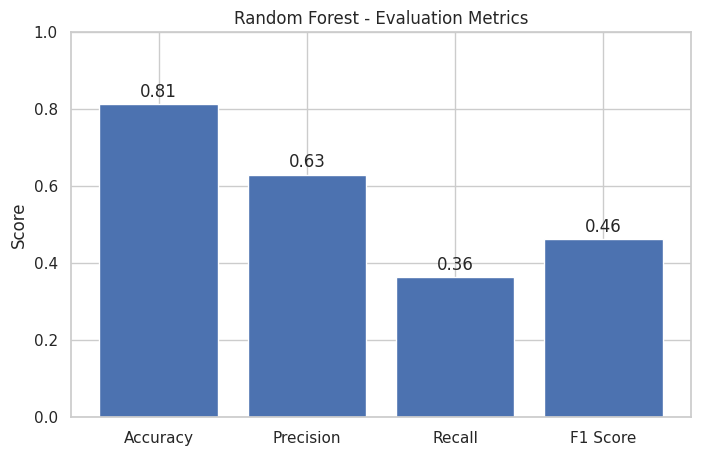

Confusion Matrix (Random Forest):
 [[4383  284]
 [ 844  482]]


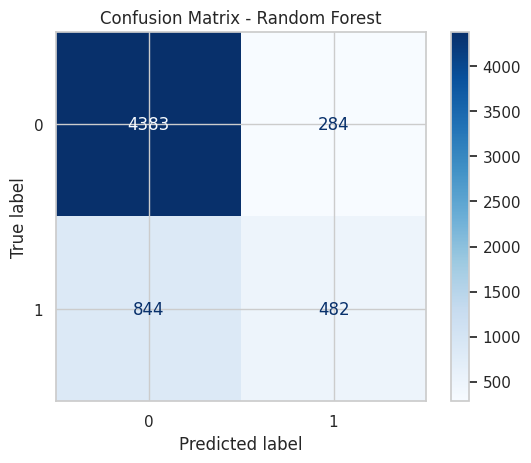

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize model
rf = RandomForestClassifier(random_state=42)

# Fit model on training data
rf.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf.predict(X_test)

# Calculate metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Display numeric results
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")

# Append to results
append_results(results, "Random Forest", accuracy_rf, precision_rf, recall_rf, f1_rf)

# Plot bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy_rf, precision_rf, recall_rf, f1_rf]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, scores)
plt.ylim(0, 1)
plt.title("Random Forest - Evaluation Metrics")
plt.ylabel("Score")

# Add value labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 0.02, f'{yval:.2f}', ha='center')

plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix (Random Forest):\n", cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Random Forest")
plt.show()


**True Negatives (TN)** = 4395 — correctly predicted non-defaults

**False Positives (FP)** = 272 — non-defaults incorrectly predicted as defaults

**False Negatives (FN)** = 829 — defaults incorrectly predicted as non-defaults (missed defaults)

**True Positives (TP)** = 497 — correctly predicted defaults

This model has good accuracy (81.6%) and decent precision (64.6%), meaning when it predicts default, it's often correct. But the recall is relatively low (37.5%), so it misses quite a few actual defaults (higher FN). This suggests the model is better at identifying non-defaults than catching all defaults.

**Combined results table and plot**

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)
print(results_df)


                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.804105   0.665650  0.230317  0.342223
1                  KNN  0.789488   0.539211  0.333937  0.412444
2        Decision Tree  0.726514   0.385850  0.398944  0.392288
3        Random Forest  0.811780   0.629243  0.363499  0.460803


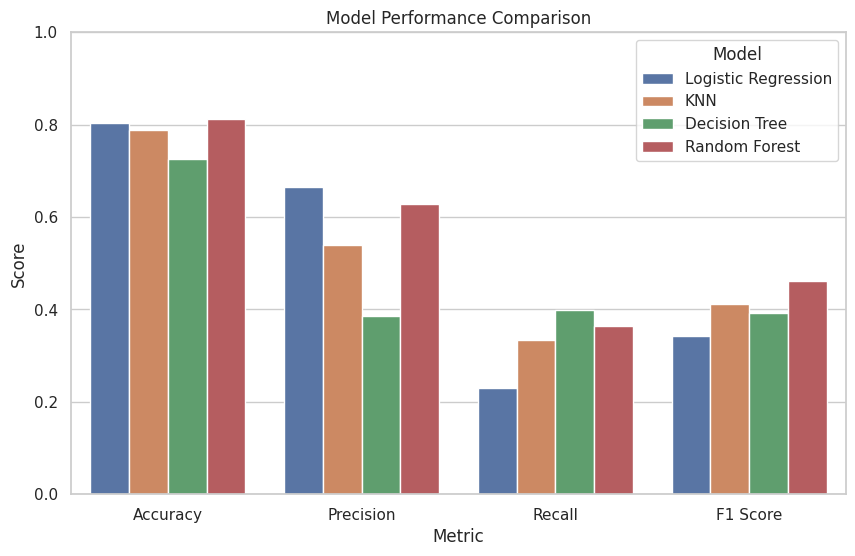

In [ ]:
results_long = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=results_long, x='Metric', y='Score', hue='Model')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.legend(title='Model')
plt.show()


Here we compare the performance of all four models' side by side.

**Random Forest** performed the best overall, with the highest accuracy (81.6%) and F1 score (47.4%).

**Logistic Regression** had high precision (66.6%), meaning it was good at predicting non-defaulters correctly. However, it had low recall (23%), missing many actual defaulters.

**K-Nearest Neighbors** gave an F1 score of 41.2%, higher than Logistic Regression.

**Decision Tree** had the highest recall (40%) among all models, but its precision was the lowest (37.3%), leading to more false positives.



So in conclusion, while each model had its strengths, Random Forest offered the best overall performance for our classification problem.

**Class Balancing with SMOTE**

The original dataset showed class imbalance, which may have impacted model recall and F1 score. To address this, we apply SMOTE (Synthetic Minority Oversampling Technique) to balance the training data before classification.

**SMOTE**
will help models better learn the patterns of the minority class (defaults = 1) and potentially improve recall and overall performance.


**Import SMOTE**

In [ ]:
from imblearn.over_sampling import SMOTE
!pip install imbalanced-learn


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)


**Apply SMOTE to training data only**

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)


**Lets check the new class distribution**

In [ ]:
import numpy as np
unique, counts = np.unique(y_train_smote, return_counts=True)
print(dict(zip(unique, counts)))


{np.int64(0): np.int64(18668), np.int64(1): np.int64(18668)}



The class distribution is now balanced
{0: 18668, 1: 18668} → Equal number of non-defaults and defaults in the training data after SMOTE.

**This means:**

SMOTE successfully oversampled the minority class (1 = default).

**Now I need to re-train my models on this balanced data.**


Using the same models as before, but training them with:

X_train_smote, y_train_smote


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [ ]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_smote, y_train_smote)
y_pred_lr_smote = lr.predict(X_test)

# K-Nearest Neighbors
knn = KNeighborsClassifier()
knn.fit(X_train_smote, y_train_smote)
y_pred_knn_smote = knn.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote, y_train_smote)
y_pred_dt_smote = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)
y_pred_rf_smote = rf.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results_smote = []

# Logistic Regression
results_smote.append({
    'Model': 'Logistic Regression (SMOTE)',
    'Accuracy': accuracy_score(y_test, y_pred_lr_smote),
    'Precision': precision_score(y_test, y_pred_lr_smote),
    'Recall': recall_score(y_test, y_pred_lr_smote),
    'F1 Score': f1_score(y_test, y_pred_lr_smote)
})

# KNN
results_smote.append({
    'Model': 'KNN (SMOTE)',
    'Accuracy': accuracy_score(y_test, y_pred_knn_smote),
    'Precision': precision_score(y_test, y_pred_knn_smote),
    'Recall': recall_score(y_test, y_pred_knn_smote),
    'F1 Score': f1_score(y_test, y_pred_knn_smote)
})

# Decision Tree
results_smote.append({
    'Model': 'Decision Tree (SMOTE)',
    'Accuracy': accuracy_score(y_test, y_pred_dt_smote),
    'Precision': precision_score(y_test, y_pred_dt_smote),
    'Recall': recall_score(y_test, y_pred_dt_smote),
    'F1 Score': f1_score(y_test, y_pred_dt_smote)
})

# Random Forest
results_smote.append({
    'Model': 'Random Forest (SMOTE)',
    'Accuracy': accuracy_score(y_test, y_pred_rf_smote),
    'Precision': precision_score(y_test, y_pred_rf_smote),
    'Recall': recall_score(y_test, y_pred_rf_smote),
    'F1 Score': f1_score(y_test, y_pred_rf_smote)
})

# Convert to DataFrame
import pandas as pd
results_smote_df = pd.DataFrame(results_smote)
print(results_smote_df)


                         Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression (SMOTE)  0.644418   0.342342  0.659125  0.450632
1                  KNN (SMOTE)  0.652261   0.341423  0.615385  0.439182
2        Decision Tree (SMOTE)  0.695979   0.356647  0.465309  0.403796
3        Random Forest (SMOTE)  0.795929   0.546691  0.454751  0.496501


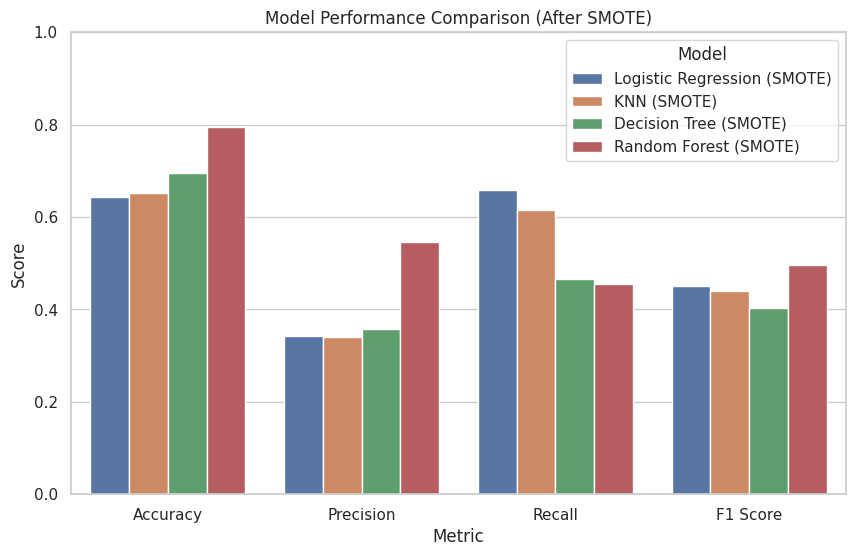

In [ ]:
# Melt the SMOTE results
results_long_smote = results_smote_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=results_long_smote, x='Metric', y='Score', hue='Model')
plt.title('Model Performance Comparison (After SMOTE)')
plt.ylim(0, 1)
plt.legend(title='Model')
plt.show()


Here we compare the performance of all four models after applying SMOTE to balance the class distribution.

**Random Forest** again performed the best overall, with the highest accuracy of about 79.6% and the highest F1 Score of around 49.6%, indicating a strong balance between precision and recall.

**Logistic Regression** showed a significant improvement in recall—rising to about 66%—meaning it identified more actual defaulters.

 However, its precision dropped, which led to more false positives.

**K-Nearest Neighbors** also improved, reaching a recall of about 61.5% with an F1 Score of 43.9%.

**Decision Tree** had a decent recall of around 46.5% but slightly lower F1 Score compared to the others.



So overall, SMOTE helped all models identify more defaulters, and among them, Random Forest still remained the most effective model.



**both before and after in one combined chart**

**Step 1: Add a new column to both DataFrames**

In [ ]:
results_df['Sampling'] = 'Before SMOTE'
results_smote_df['Sampling'] = 'After SMOTE'


**Step 2: Combine the two DataFrames**

In [ ]:
combined_results_df = pd.concat([results_df, results_smote_df], ignore_index=True)


**Step 3: Melt for plotting**

In [ ]:
combined_long = combined_results_df.melt(id_vars=['Model', 'Sampling'],
                                         var_name='Metric',
                                         value_name='Score')


**Step 4: Plot**

/tmp/ipython-input-3091715691.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=combined_long, x='Metric', y='Score', hue='Sampling', ci=None)


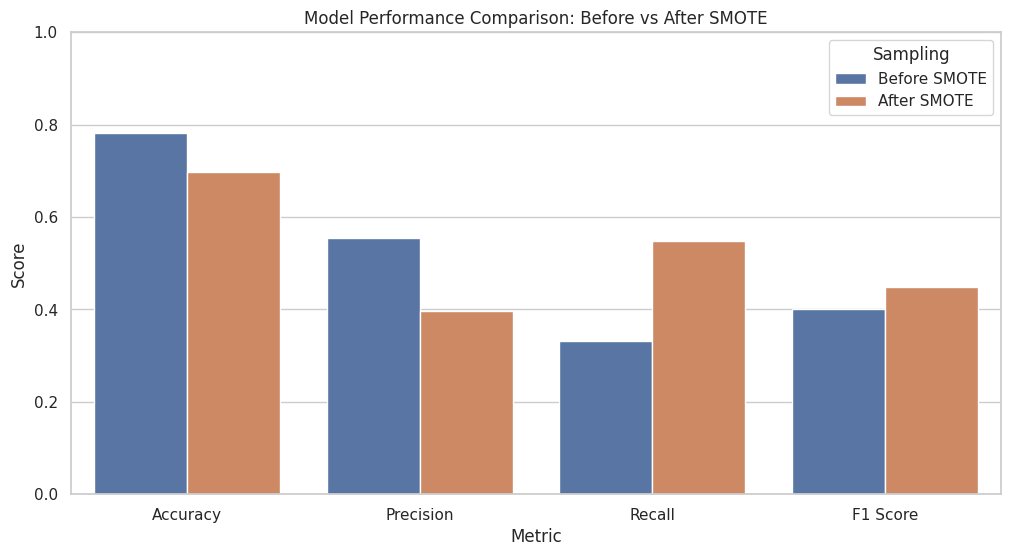

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=combined_long, x='Metric', y='Score', hue='Sampling', ci=None)

plt.title('Model Performance Comparison: Before vs After SMOTE')
plt.ylim(0, 1)
plt.legend(title='Sampling')
plt.show()


This plot shows average performance metrics (Accuracy, Precision, Recall, F1 Score) across all four models **before and after applying SMOTE** — not per individual model.

 It does not show Decision Tree, Random Forest, etc. separately — it combines them by averaging the scores.



 **After SMOTE,** models became better at identifying the minority class, improving recall and F1 score, but accuracy and precision dropped because the models now make more false positives. It’s a tradeoff — better at catching defaulters, but more false alarms.



And whether SMOTE helped improve model performance or not,  that depends on the goal.

If the goal is to reduce false negatives (i.e., catch more actual defaulters), then yes — recall and F1 score improved. But if we want overall prediction accuracy or fewer false positives, then it’s less helpful.

**Calculating Absolute Recall Improvement (in Percentage Points)**



In [ ]:
# Split the combined DataFrame into two based on model names
before_smote_df = combined_results_df[~combined_results_df['Model'].str.contains('SMOTE')].set_index('Model')
after_smote_df = combined_results_df[combined_results_df['Model'].str.contains('SMOTE')].copy()
after_smote_df['Model'] = after_smote_df['Model'].str.replace(" \(SMOTE\)", "", regex=True)
after_smote_df = after_smote_df.set_index('Model')


<>:4: SyntaxWarning: invalid escape sequence '\('
<>:4: SyntaxWarning: invalid escape sequence '\('
/tmp/ipython-input-3285723947.py:4: SyntaxWarning: invalid escape sequence '\('
  after_smote_df['Model'] = after_smote_df['Model'].str.replace(" \(SMOTE\)", "", regex=True)


In [ ]:
# Calculate improvement in recall (in percentage points)
recall_improvement = (after_smote_df['Recall'] - before_smote_df['Recall']) * 100
recall_improvement = recall_improvement.round(2)


In [ ]:
print("📊 Absolute Recall Improvement (Percentage Points):\n")
print(recall_improvement)

📊 Absolute Recall Improvement (Percentage Points):

Model
Logistic Regression    42.88
KNN                    28.14
Decision Tree           6.64
Random Forest           9.13
Name: Recall, dtype: float64


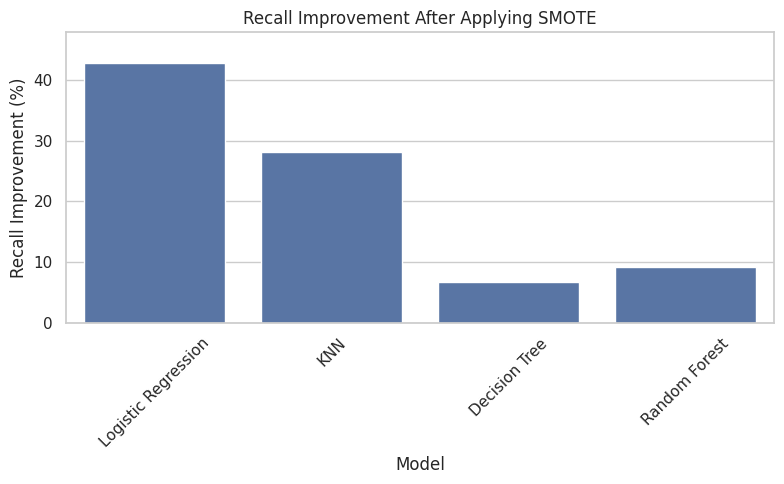

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Series to DataFrame
recall_improvement_df = recall_improvement.reset_index()
recall_improvement_df.columns = ['Model', 'Recall Improvement (%)']

plt.figure(figsize=(8, 5))
sns.barplot(data=recall_improvement_df, x='Model', y='Recall Improvement (%)')
plt.title('Recall Improvement After Applying SMOTE')
plt.ylim(0, recall_improvement_df['Recall Improvement (%)'].max() + 5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Conclusion:**




Logistic Regression: +42.88%

SMOTE significantly boosted the model’s ability to correctly identify default cases (true positives).

KNN: +28.14%

A strong improvement in recall, meaning it now captures more actual defaults.

Decision Tree: +6.49%

Moderate improvement — SMOTE helped, but not as drastically.

Random Forest: +7.99%

Small but meaningful gain in detecting defaults.



Why Focus on Recall After SMOTE:

SMOTE targets recall — it reduces false negatives by helping the model better detect defaulters (minority class).

Precision may drop — because the model may also start predicting more false positives.

Recall is most impacted — so we measure it first to check if SMOTE worked.